# CISI Future Projections
Runs the trained CNN on SSP scenario inputs for 2030, 2050, and 2100.
Fill in the file paths marked `# TODO` before running.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
from pathlib import Path
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
import sys as _sys; _sys.path.insert(0, __import__('os').path.abspath('.'))
from src.fill import fill_input_stack
from rasterio.features import rasterize
from shapely.geometry import mapping
import pandas as pd
from rasterio.transform import xy as rasterio_xy
from shapely.geometry import Point
from scipy.ndimage import generic_filter
import numpy as np, matplotlib.pyplot as plt, matplotlib.colors as mcolors
import geopandas as gpd, rasterio
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np, rasterio, pandas as pd

In [3]:
class CNNSweep(nn.Module):
    def __init__(self, config):
        super().__init__()
        d = config.get('dropout', 0.3)
        n_layers = config.get('n_layers', 4)
        base_ch  = config.get('base_channels', 16)
        layers = []; in_ch = 9; out_ch = base_ch
        for i in range(n_layers):
            layers += [nn.Conv2d(in_ch, out_ch, 3, padding=1),
                       nn.BatchNorm2d(out_ch), nn.ReLU(), nn.Dropout(d)]
            if i < n_layers - 1:
                layers.append(nn.MaxPool2d(2, 2))
            in_ch = out_ch; out_ch = min(out_ch * 2, 256)
        self.conv_layers = nn.Sequential(*layers)
        self.fc_layers   = nn.Sequential(
            nn.Linear(in_ch, 32), nn.BatchNorm1d(32),
            nn.ReLU(), nn.Dropout(d), nn.Linear(32, 1))

    def forward(self, x):
        x = self.conv_layers(x)
        x = x[:, :, 1, 1]
        return torch.sigmoid(self.fc_layers(x))


## Paths fill in before running

In [4]:
MODEL_PATH  = 'best_sweep_final_model.pt'
OUTPUT_DIR  = 'projections_output'   # GeoTIFFs
FIGURES_DIR = 'projections_output/figures'

REFERENCE_RASTER = r'READY_data\labels\2024_CISI_010deg_nearest.tif'
SHP_PATH         = r'ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp'

os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

NORM_DIR = r'READY_data\inputs_normalized\ssp'

SCENARIOS = {
    'SSP1': {
        2030: {
            'gdp': rf'{NORM_DIR}\GDP_SSP1_2030_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP1_2030_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP1_2030_class_{c}.tif' for c in range(1, 8)],
        },
        2050: {
            'gdp': rf'{NORM_DIR}\GDP_SSP1_2050_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP1_2050_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP1_2050_class_{c}.tif' for c in range(1, 8)],
        },
        2100: {
            'gdp': rf'{NORM_DIR}\GDP_SSP1_2100_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP1_2100_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP1_2100_class_{c}.tif' for c in range(1, 8)],
        },
    },
    'SSP2': {
        2030: {
            'gdp': rf'{NORM_DIR}\GDP_SSP2_2030_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP2_2030_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP2_2030_class_{c}.tif' for c in range(1, 8)],
        },
        2050: {
            'gdp': rf'{NORM_DIR}\GDP_SSP2_2050_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP2_2050_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP2_2050_class_{c}.tif' for c in range(1, 8)],
        },
        2100: {
            'gdp': rf'{NORM_DIR}\GDP_SSP2_2100_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP2_2100_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP2_2100_class_{c}.tif' for c in range(1, 8)],
        },
    },
    'SSP3': {
        2030: {
            'gdp': rf'{NORM_DIR}\GDP_SSP3_2030_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP3_2030_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP3_2030_class_{c}.tif' for c in range(1, 8)],
        },
        2050: {
            'gdp': rf'{NORM_DIR}\GDP_SSP3_2050_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP3_2050_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP3_2050_class_{c}.tif' for c in range(1, 8)],
        },
        2100: {
            'gdp': rf'{NORM_DIR}\GDP_SSP3_2100_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP3_2100_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP3_2100_class_{c}.tif' for c in range(1, 8)],
        },
    },
    'SSP4': {
        2030: {
            'gdp': rf'{NORM_DIR}\GDP_SSP4_2030_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP4_2030_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP4_2030_class_{c}.tif' for c in range(1, 8)],
        },
        2050: {
            'gdp': rf'{NORM_DIR}\GDP_SSP4_2050_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP4_2050_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP4_2050_class_{c}.tif' for c in range(1, 8)],
        },
        2100: {
            'gdp': rf'{NORM_DIR}\GDP_SSP4_2100_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP4_2100_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP4_2100_class_{c}.tif' for c in range(1, 8)],
        },
    },
    'SSP5': {
        2030: {
            'gdp': rf'{NORM_DIR}\GDP_SSP5_2030_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP5_2030_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP5_2030_class_{c}.tif' for c in range(1, 8)],
        },
        2050: {
            'gdp': rf'{NORM_DIR}\GDP_SSP5_2050_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP5_2050_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP5_2050_class_{c}.tif' for c in range(1, 8)],
        },
        2100: {
            'gdp': rf'{NORM_DIR}\GDP_SSP5_2100_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP5_2100_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP5_2100_class_{c}.tif' for c in range(1, 8)],
        },
    },
}

## Load model

In [5]:
ckpt = torch.load(MODEL_PATH, map_location=device)
projection_model = CNNSweep(ckpt['config']).to(device)
projection_model.load_state_dict(ckpt['model_state_dict'])
projection_model.eval()
print(f'Loaded {MODEL_PATH}')
print(f'Config: {ckpt["config"]}')

Loaded best_sweep_final_model.pt
Config: {'patch_size': 8, 'n_layers': 2, 'base_channels': 32, 'dropout': 0.17454852770248158, 'lr': 0.00011146905836052476, 'weight_decay': 9.910996083741572e-05, 'batch_size': 64, 'loss_fn': 'weighted_mse', 'scale': 100, 'oversample_factor': 20}


## Helper: load and align raster to reference grid

In [ ]:
def load_aligned(path, ref_shape, ref_transform, ref_crs):
    with rasterio.open(path) as src:
        data = src.read().astype(np.float32)
    if (data.shape[1], data.shape[2]) != ref_shape:
        raise ValueError(f'Shape mismatch in {os.path.basename(path)}: {data.shape[1:]} != {ref_shape}')
    return data


def build_input_stack(gdp_path, pop_path, lc_paths, ref_shape, ref_transform, ref_crs):
    gdp = load_aligned(gdp_path, ref_shape, ref_transform, ref_crs)[0]
    pop = load_aligned(pop_path, ref_shape, ref_transform, ref_crs)[0]
    lc  = np.concatenate([load_aligned(p, ref_shape, ref_transform, ref_crs) for p in lc_paths], axis=0)
    stack = np.stack([gdp, pop, *lc], axis=0)
    return fill_input_stack(stack)


# EU27 country names as they appear in the Natural Earth shapefile
EU27 = {
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia',
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
    'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg',
    'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia',
    'Slovenia', 'Spain', 'Sweden',
}

with rasterio.open(REFERENCE_RASTER) as ref:
    REF_SHAPE     = (ref.height, ref.width)
    REF_TRANSFORM = ref.transform
    REF_CRS       = ref.crs
    REF_PROFILE   = ref.profile.copy()


world = gpd.read_file(SHP_PATH)
eu27_geoms = world[world['NAME'].isin(EU27)]['geometry']
matched = world[world['NAME'].isin(EU27)]['NAME'].unique()
missing = EU27 - set(matched)
if missing:
    print('WARNING — names not matched in shapefile:', missing)

VALID_MASK = rasterize(
    [(mapping(geom), 1) for geom in eu27_geoms],
    out_shape=REF_SHAPE,
    transform=REF_TRANSFORM,
    fill=0,
    dtype='uint8',
).astype(bool)

print(f'Reference grid: {REF_SHAPE}, CRS: {REF_CRS}')
print(f'EU27 (incl. Italy) valid pixels: {VALID_MASK.sum():,}')

# Save complete EU27 mask (incl. Italy)
_profile = REF_PROFILE.copy()
_profile.update(dtype='uint8', count=1, nodata=0)
with rasterio.open(r'READY_data\labels\eu_mask_010deg.tif', 'w', **_profile) as dst:
    dst.write(VALID_MASK.astype('uint8')[np.newaxis])
print('Saved: READY_data/labels/eu_mask_010deg.tif')

## Pre-flight alignment check

Verifies that every input file for every scenario has the correct shape, CRS, and transform before any inference runs. Stops early if anything is misaligned.

In [7]:
issues = []

for ssp, years in SCENARIOS.items():
    for year, paths in years.items():
        all_paths = [paths['gdp'], paths['pop']] + paths['lc']
        for p in all_paths:
            if not os.path.exists(p):
                issues.append(f'MISSING   {ssp} {year}: {os.path.basename(p)}')
                continue
            with rasterio.open(p) as src:
                shape = (src.height, src.width)
                crs   = src.crs
                transform = src.transform
            if shape != REF_SHAPE:
                issues.append(f'SHAPE     {ssp} {year}: {os.path.basename(p)} — {shape} != {REF_SHAPE}')
            if crs != REF_CRS:
                issues.append(f'CRS       {ssp} {year}: {os.path.basename(p)} — {crs} != {REF_CRS}')
            if not all(abs(transform[i] - REF_TRANSFORM[i]) < 1e-6 for i in range(6)):
                issues.append(f'TRANSFORM {ssp} {year}: {os.path.basename(p)} — transform mismatch')

if issues:
    print(f'FOUND {len(issues)} ISSUE(S) — fix before running projections:\n')
    for iss in issues:
        print(f'  {iss}')
    raise RuntimeError('Input alignment check failed. See issues above.')
else:
    print(f'All inputs verified — {sum(len(y) * 9 for y in SCENARIOS.values())} files checked. Ready to run.')

All inputs verified — 135 files checked. Ready to run.


In [8]:
PATCH_SIZE = ckpt['config'].get('patch_size', 8)
HALF       = PATCH_SIZE // 2

def predict_raster(input_stack):
    H, W = REF_SHAPE
    pred_map = np.full((H, W), np.nan, dtype=np.float32)
    valid_idx = np.argwhere(VALID_MASK)
    patches, coords = [], []

    for i, j in valid_idx:
        pad_top    = max(0, HALF - i)
        pad_bottom = max(0, (i + HALF) - H)
        pad_left   = max(0, HALF - j)
        pad_right  = max(0, (j + HALF) - W)
        i0 = max(0, i - HALF); i1 = min(H, i + HALF)
        j0 = max(0, j - HALF); j1 = min(W, j + HALF)
        patch = input_stack[:, i0:i1, j0:j1].copy()
        if pad_top or pad_bottom or pad_left or pad_right:
            patch = np.pad(patch, ((0,0),(pad_top,pad_bottom),(pad_left,pad_right)), mode='edge')
        patches.append(patch)
        coords.append((i, j))

        if len(patches) == 512:
            batch = torch.FloatTensor(np.stack(patches)).to(device)
            with torch.no_grad():
                preds = projection_model(batch).cpu().numpy().flatten()
            for (pi, pj), p in zip(coords, preds):
                pred_map[pi, pj] = p
            patches, coords = [], []

    if patches:
        batch = torch.FloatTensor(np.stack(patches)).to(device)
        with torch.no_grad():
            preds = projection_model(batch).cpu().numpy().flatten()
        for (pi, pj), p in zip(coords, preds):
            pred_map[pi, pj] = p

    return pred_map


results = {}

for ssp, years in SCENARIOS.items():
    results[ssp] = {}
    for year, paths in years.items():
        missing = [p for p in [paths['gdp'], paths['pop']] + paths['lc'] if not os.path.exists(p)]
        if missing:
            print(f'SKIPPING {ssp} {year} — missing files:')
            for m in missing: print(f'  {m}')
            continue

        print(f'Running {ssp} {year}...')
        stack = build_input_stack(
            paths['gdp'], paths['pop'], paths['lc'],
            REF_SHAPE, REF_TRANSFORM, REF_CRS
        )
        pred = predict_raster(stack)
        results[ssp][year] = pred

        out_path = f'{OUTPUT_DIR}/cisi_pred_{ssp}_{year}.tif'
        profile = REF_PROFILE.copy()
        profile.update(dtype='float32', count=1, nodata=np.nan)
        with rasterio.open(out_path, 'w', **profile) as dst:
            dst.write(pred[np.newaxis, :, :])
        print(f'  Saved {out_path}  |  mean={np.nanmean(pred):.4f}  max={np.nanmax(pred):.4f}')

print('\nDone.')

Running SSP1 2030...
  Saved projections_output/cisi_pred_SSP1_2030.tif  |  mean=0.0637  max=0.5289
Running SSP1 2050...
  Saved projections_output/cisi_pred_SSP1_2050.tif  |  mean=0.0665  max=0.4890
Running SSP1 2100...
  Saved projections_output/cisi_pred_SSP1_2100.tif  |  mean=0.0667  max=0.4554
Running SSP2 2030...
  Saved projections_output/cisi_pred_SSP2_2030.tif  |  mean=0.0641  max=0.5075
Running SSP2 2050...
  Saved projections_output/cisi_pred_SSP2_2050.tif  |  mean=0.0666  max=0.5043
Running SSP2 2100...
  Saved projections_output/cisi_pred_SSP2_2100.tif  |  mean=0.0690  max=0.4799
Running SSP3 2030...
  Saved projections_output/cisi_pred_SSP3_2030.tif  |  mean=0.0636  max=0.5241
Running SSP3 2050...
  Saved projections_output/cisi_pred_SSP3_2050.tif  |  mean=0.0637  max=0.5136
Running SSP3 2100...
  Saved projections_output/cisi_pred_SSP3_2100.tif  |  mean=0.0623  max=0.5125
Running SSP4 2030...
  Saved projections_output/cisi_pred_SSP4_2030.tif  |  mean=0.0641  max=0.4992


## Maps one figure per year, all SSPs

In [9]:
if "results" not in dir() or not any(results.get(s) for s in ["SSP1","SSP2","SSP3","SSP4","SSP5"]):
    print("results not in memory — loading from TIF files...")
    results = {}
    for ssp in ["SSP1","SSP2","SSP3","SSP4","SSP5"]:
        results[ssp] = {}
        for year in [2030, 2050, 2100]:
            path = f"{OUTPUT_DIR}/cisi_pred_{ssp}_{year}.tif"
            with rasterio.open(path) as src:
                results[ssp][year] = src.read(1).astype(np.float32)
            print(f"  Loaded {ssp}-{year}")
    print("Done.")
else:
    n = sum(len(v) for v in results.values())
    print(f"results already in memory ({n} maps — skipping TIF load)")

results already in memory (15 maps — skipping TIF load)


Saved projections_output/figures/projections_2030.png


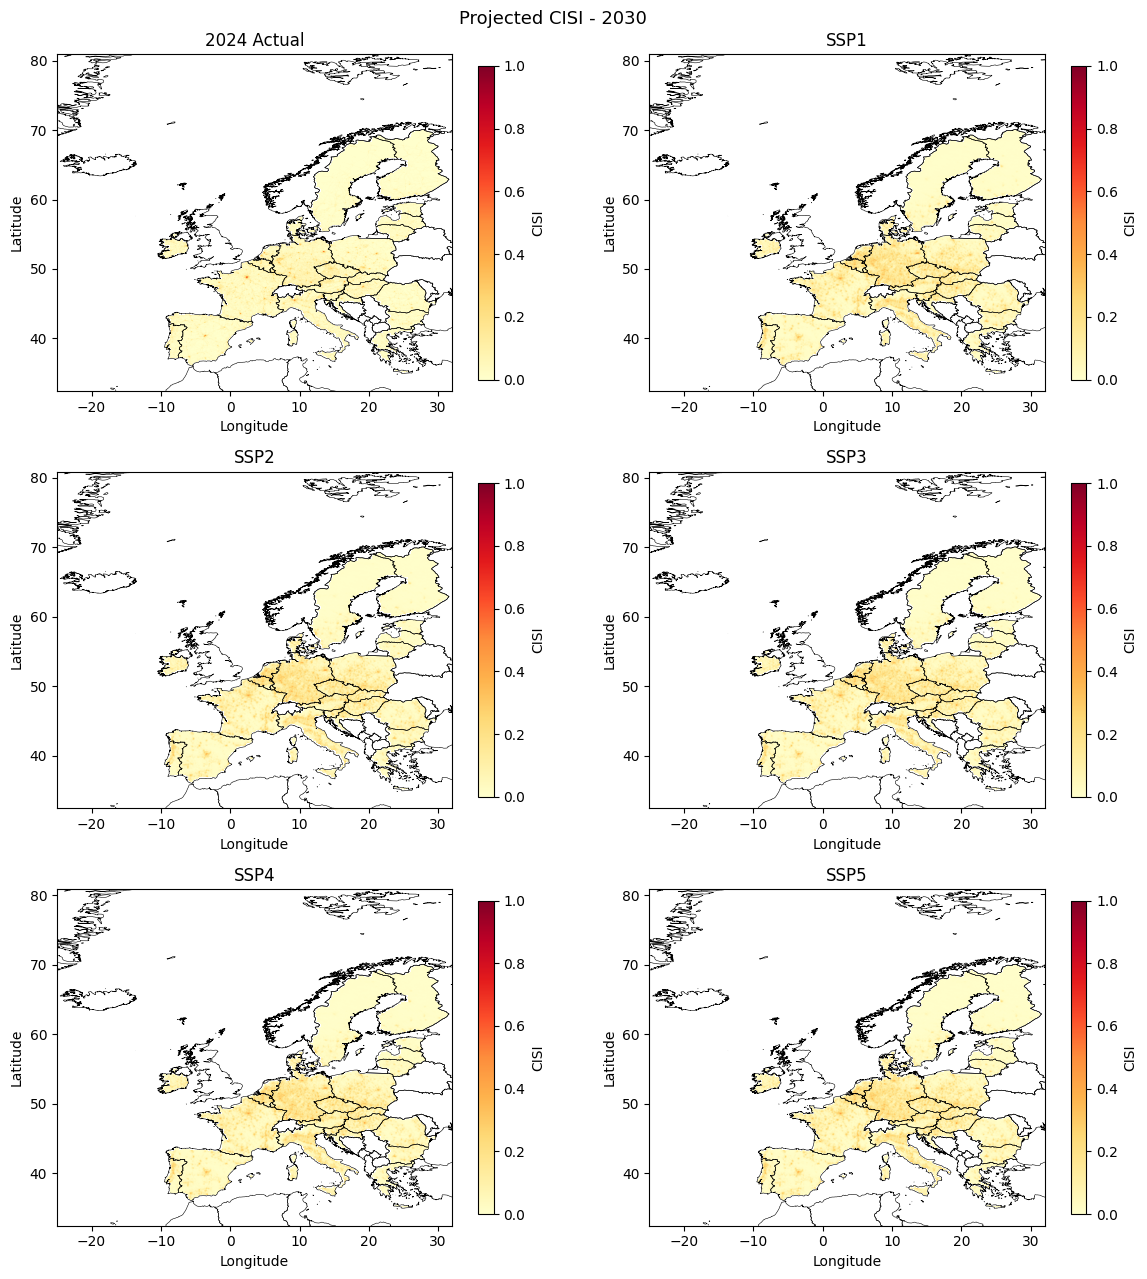

Saved projections_output/figures/projections_2050.png


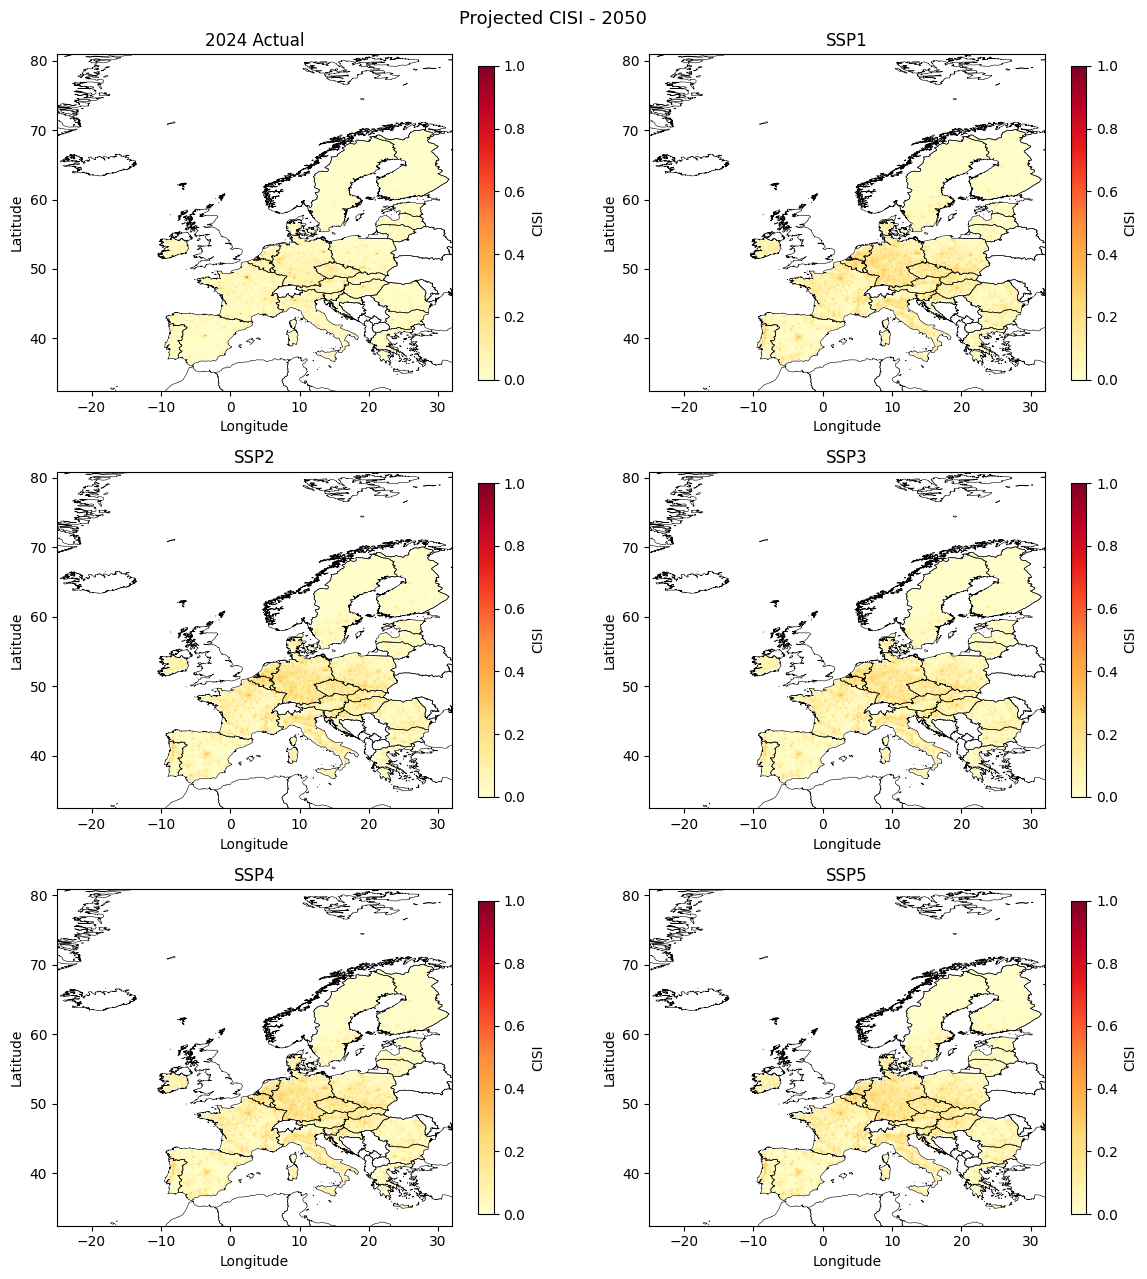

Saved projections_output/figures/projections_2100.png


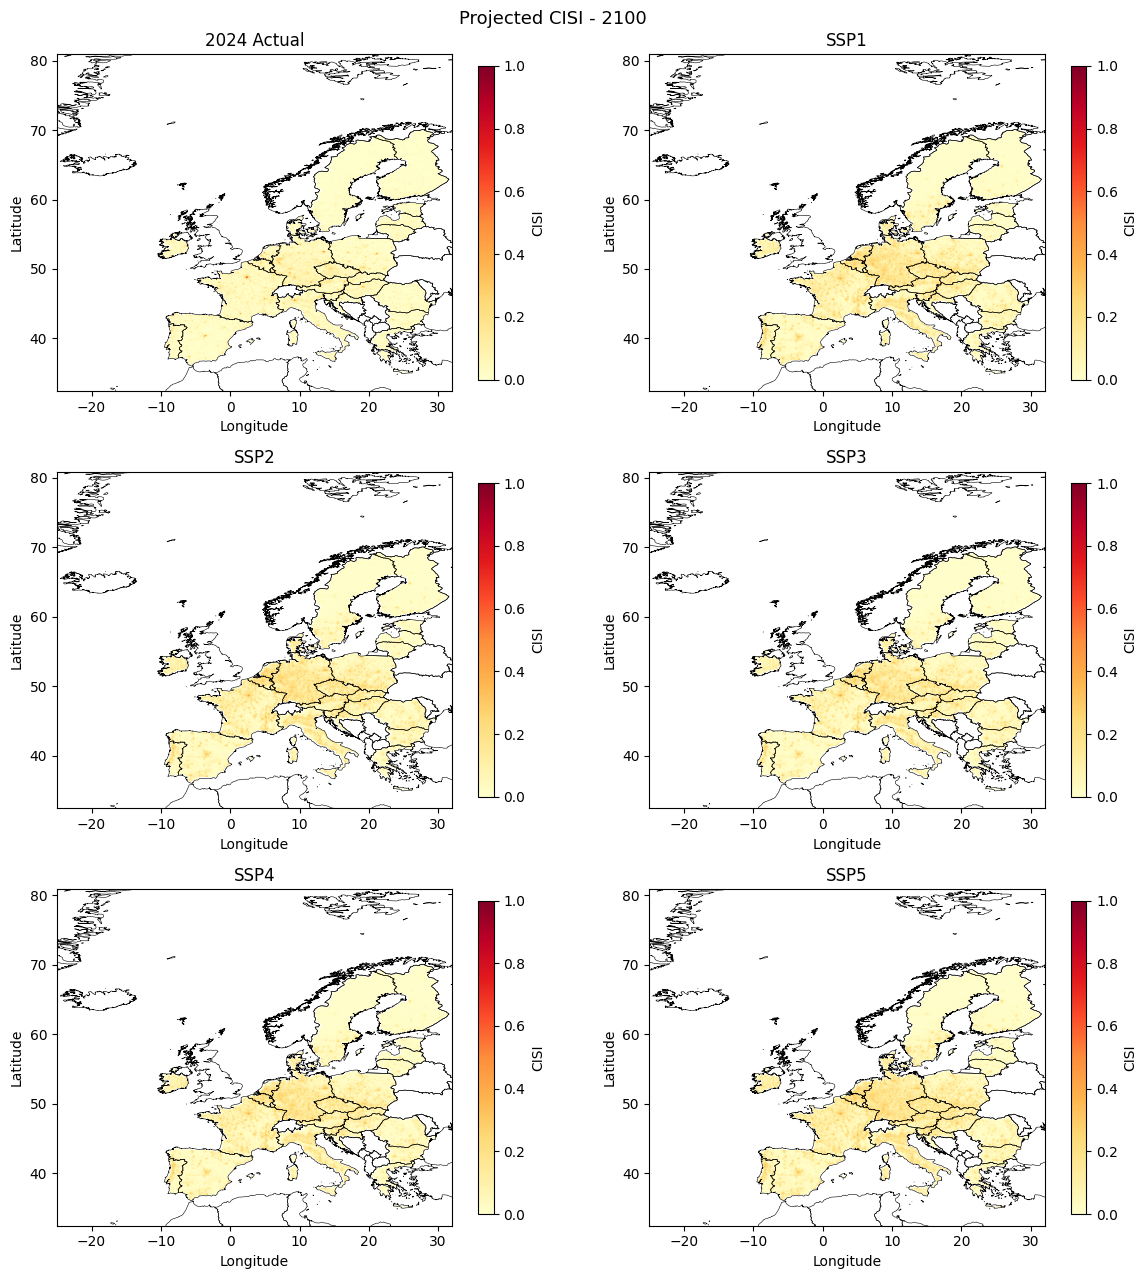

In [10]:
world = gpd.read_file(SHP_PATH)

SSPS  = [s for s in SCENARIOS if results.get(s)]
YEARS = [2030, 2050, 2100]

with rasterio.open(REFERENCE_RASTER) as ref:
    bounds    = ref.bounds
    cisi_2024 = ref.read(1).astype(np.float32)

cisi_2024_masked = np.where(VALID_MASK, cisi_2024, np.nan)
ext = [bounds.left, bounds.right, bounds.bottom, bounds.top]

for year in YEARS:
    ssps_with_data = [s for s in SSPS if year in results.get(s, {})]
    panels = [('2024 Actual', cisi_2024_masked)] + [(ssp, results[ssp][year]) for ssp in ssps_with_data]

    fig, axes = plt.subplots(3, 2, figsize=(12, 13))
    fig.suptitle(f'Projected CISI - {year}', fontsize=13)

    for ax, (title, data) in zip(axes.flat, panels):
        im = ax.imshow(data, cmap='YlOrRd', vmin=0, vmax=1.0,
                       extent=ext, origin='upper', aspect='auto')
        world.boundary.plot(ax=ax, linewidth=0.4, color='black')
        ax.set_xlim(bounds.left, bounds.right)
        ax.set_ylim(bounds.bottom, bounds.top)
        ax.set_title(title)
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        plt.colorbar(im, ax=ax, label='CISI', fraction=0.03)

    plt.tight_layout()
    out_fig = f'{FIGURES_DIR}/projections_{year}.png'
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f'Saved {out_fig}')
    plt.show()

In [ ]:
with rasterio.open(REFERENCE_RASTER) as src:
    cisi_2024_full = src.read(1).astype(np.float32)

def compute_stats(arr, mask):
    vals      = arr[mask]
    vals      = vals[~np.isnan(vals)]
    city_mask = vals > 0.15
    return {
        'mean':       float(vals.mean()),
        'std':        float(vals.std()),
        'max':        float(vals.max()),
        'pct_city':   float(city_mask.mean() * 100),
        'city_mean':  float(vals[city_mask].mean()) if city_mask.sum() > 0 else float('nan'),
    }

rows = []

# 2021 baseline
s = compute_stats(cisi_2024_full, VALID_MASK)
rows.append({'Source': '2021 Actual', 'Mean': s['mean'], 'Std': s['std'],
             'Max': s['max'], '% >0.15': s['pct_city'], 'City Mean': s['city_mean']})

# 2030 projections per SSP
for ssp in SSPS:
    if 2030 not in results.get(ssp, {}):
        continue
    s = compute_stats(results[ssp][2030], VALID_MASK)
    rows.append({'Source': f'{ssp} 2030', 'Mean': s['mean'], 'Std': s['std'],
                 'Max': s['max'], '% >0.15': s['pct_city'], 'City Mean': s['city_mean']})

df_cmp = pd.DataFrame(rows).set_index('Source')
print(df_cmp.to_string(float_format=lambda x: f'{x:.4f}'))

## Per-year overview — 2×3 grid (2021 actual + SSP1–5)

Saved projections_output/figures/full_distribution_overview_2030.png


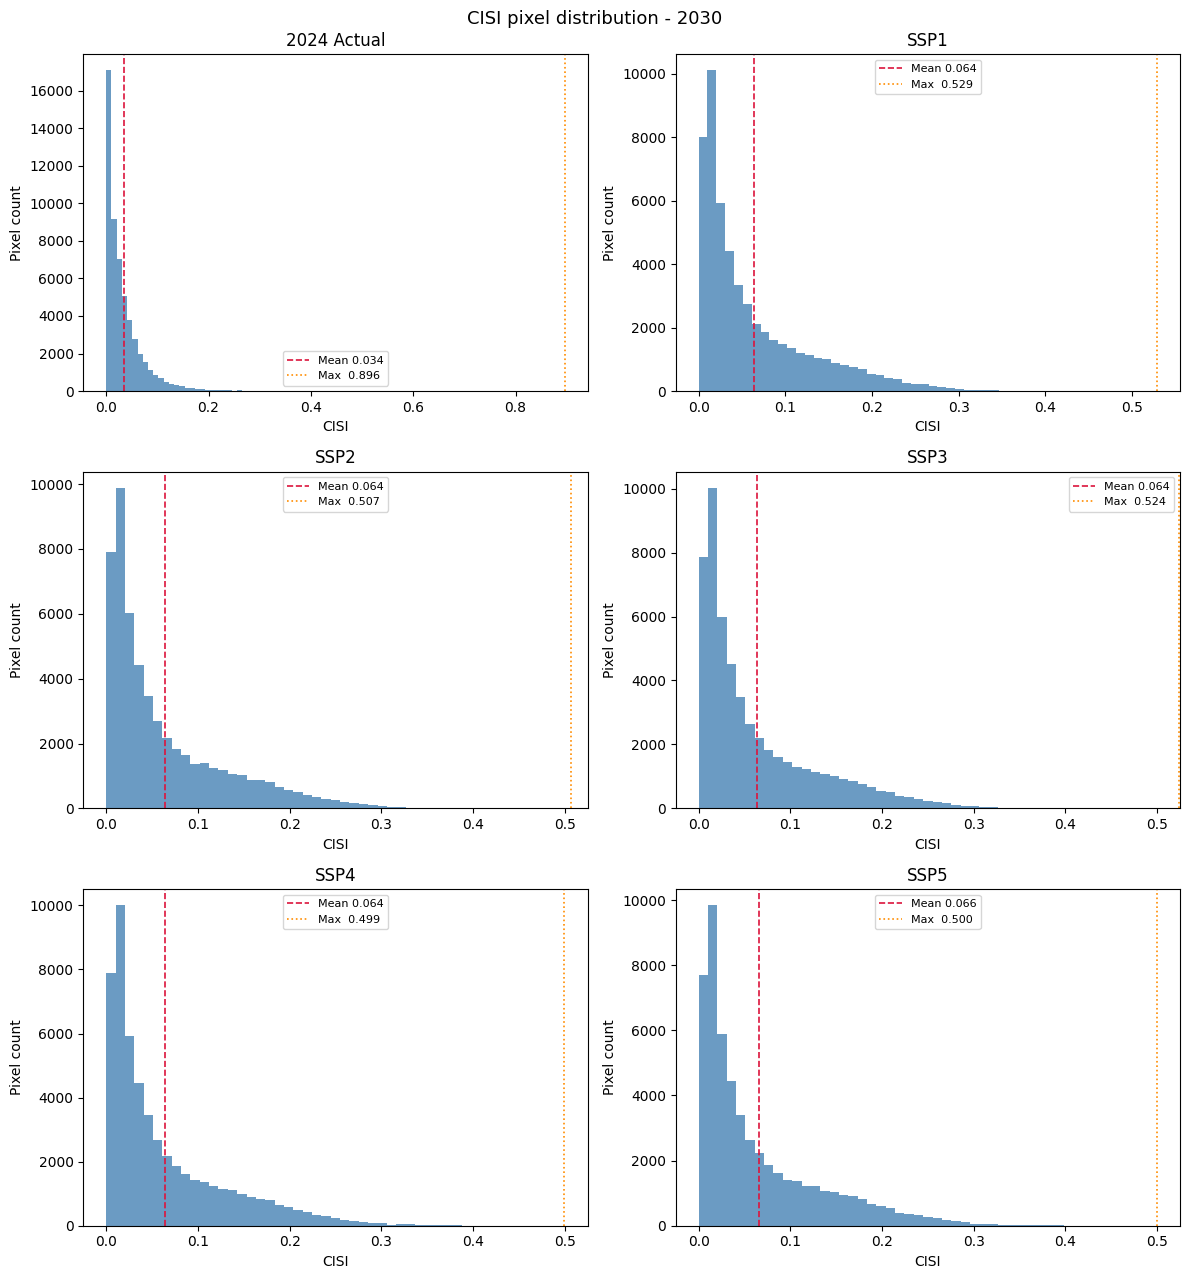

Saved projections_output/figures/full_distribution_overview_2050.png


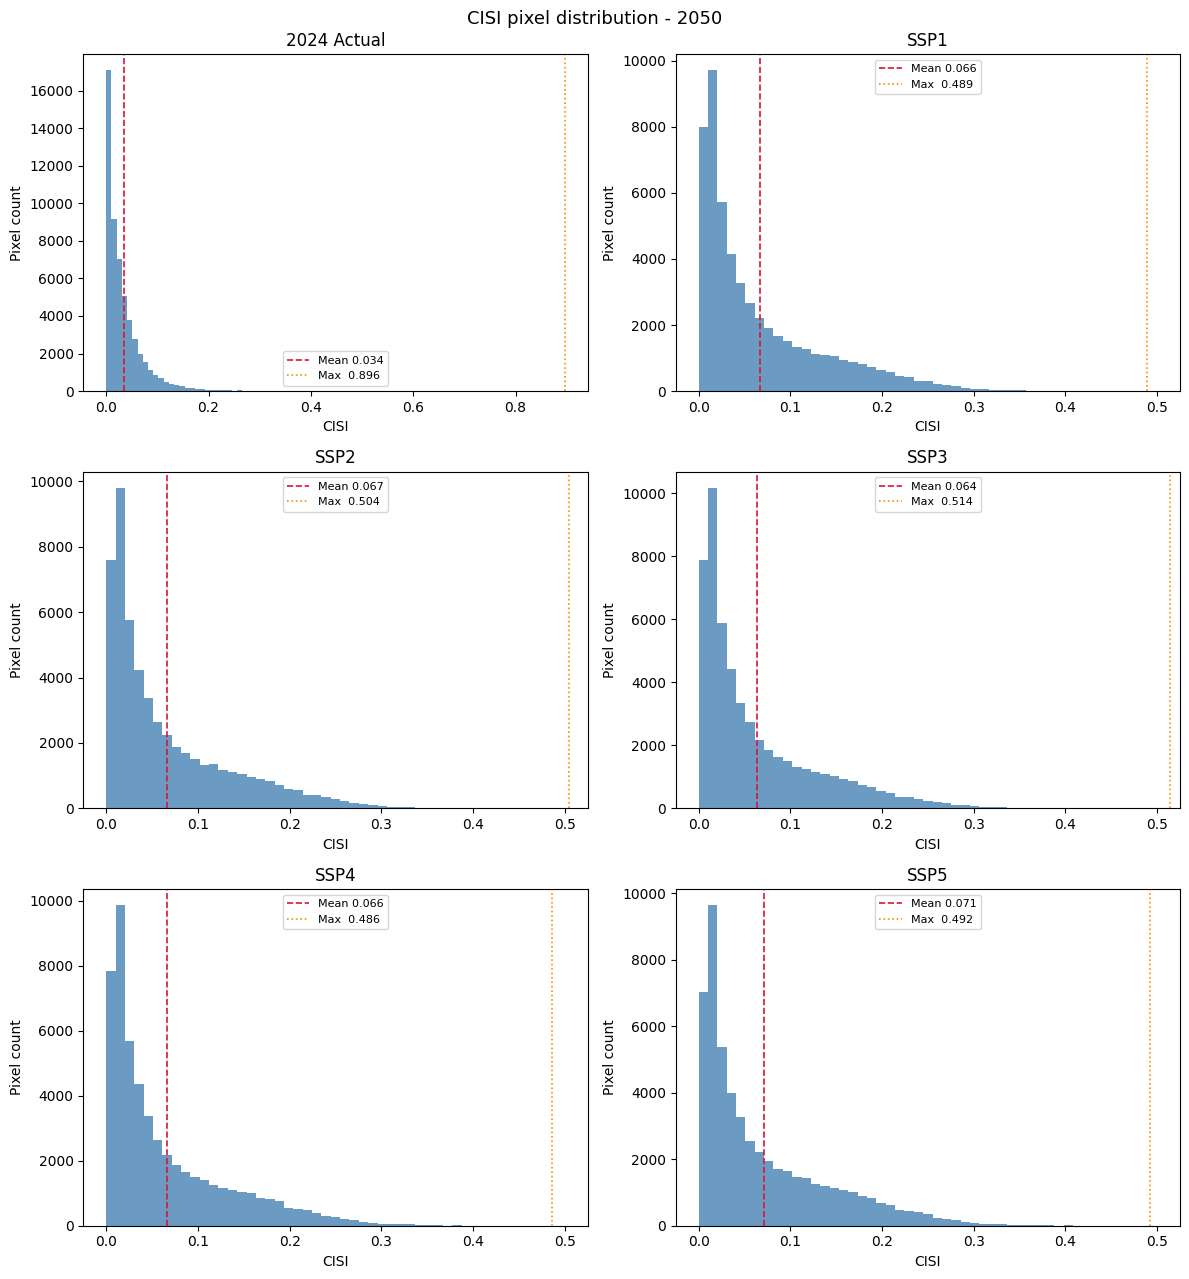

Saved projections_output/figures/full_distribution_overview_2100.png


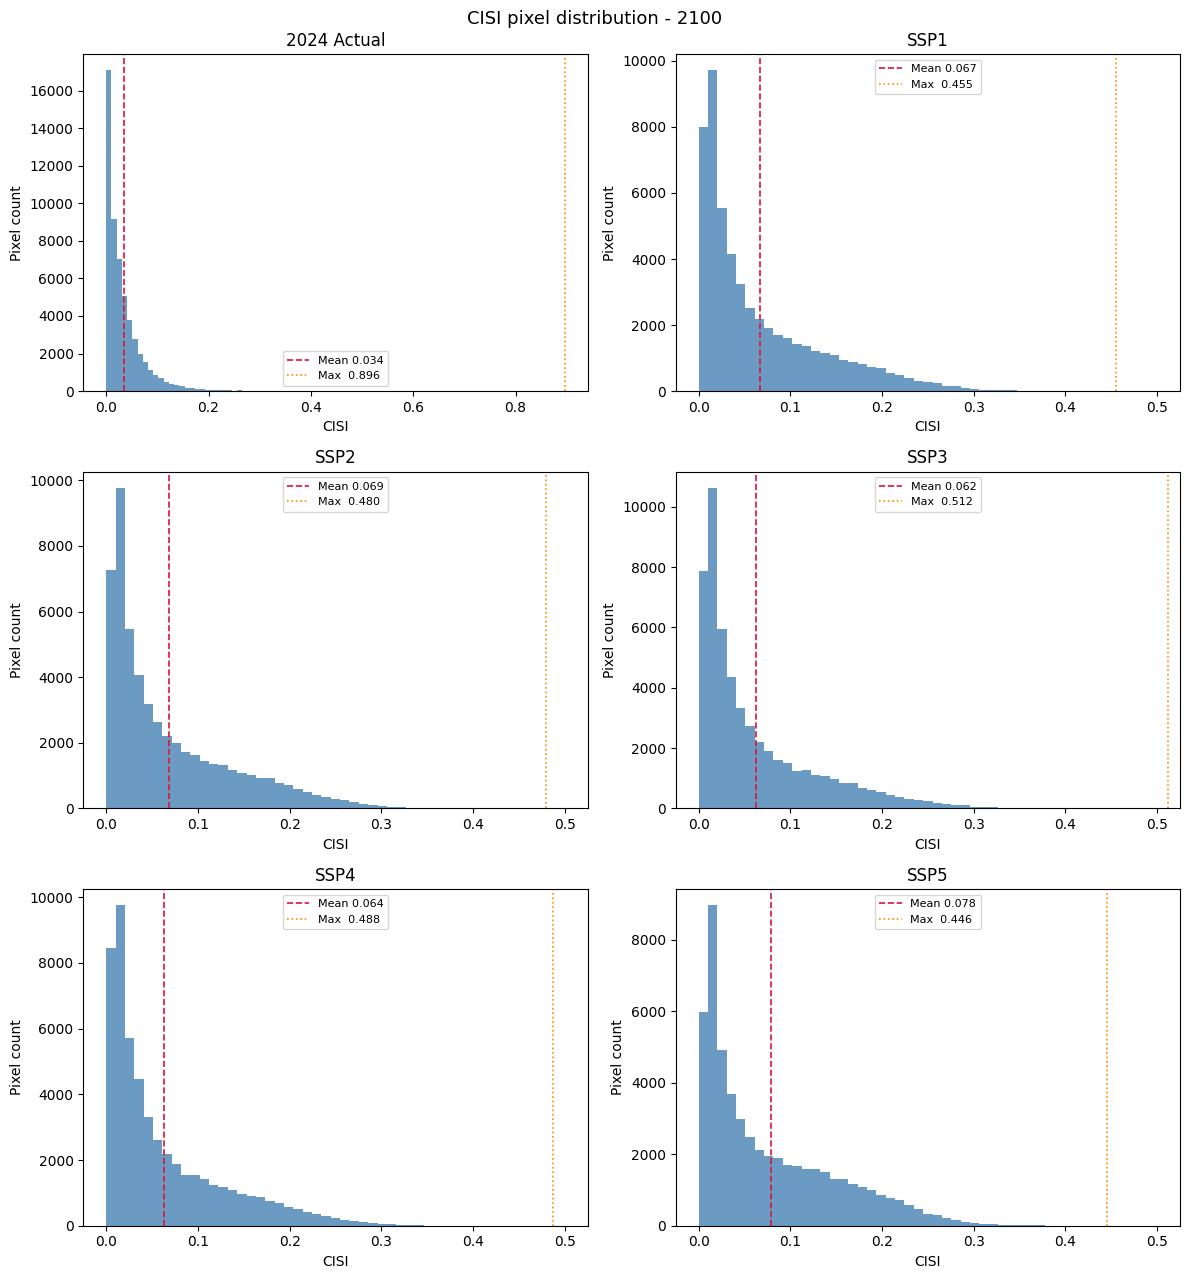

In [12]:
bins = np.linspace(0, 0.5, 50)

for year in YEARS:
    panels = [
        ('2024 Actual', cisi_2024_masked),
        ('SSP1',        results['SSP1'][year]),
        ('SSP2',        results['SSP2'][year]),
        ('SSP3',        results['SSP3'][year]),
        ('SSP4',        results['SSP4'][year]),
        ('SSP5',        results['SSP5'][year]),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(12, 13))
    fig.suptitle(f'CISI pixel distribution - {year}', fontsize=13)

    for ax, (title, data) in zip(axes.flat, panels):
        vals = data[~np.isnan(data)]
        ax.hist(vals, bins=bins, color='steelblue', alpha=0.8)
        ax.axvline(vals.mean(), color='crimson',    linestyle='--', linewidth=1.2, label=f'Mean {vals.mean():.3f}')
        ax.axvline(vals.max(),  color='darkorange', linestyle=':',  linewidth=1.2, label=f'Max  {vals.max():.3f}')
        ax.set_title(title)
        ax.set_xlabel('CISI'); ax.set_ylabel('Pixel count')
        ax.legend(fontsize=8)

    plt.tight_layout()
    out_fig = f'{FIGURES_DIR}/full_distribution_overview_{year}.png'
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f'Saved {out_fig}')
    plt.show()

## SSP scenario difference analysis

Compares SSP scenarios against each other and over time. Shows: (1) summary stats table, (2) mean CISI over time per SSP, (3) spatial difference maps between SSP1 and SSP5 per year, (4) per-SSP spread across years.

## Model limitation diagnostics

Three figures documenting why projections should be interpreted with caution:
1. **Prediction ceiling** — model output is capped well below observed CISI values
2. **GDP out-of-distribution extrapolation** — SSP GDP values far exceed training range
3. **Scenario indistinguishability** — key metrics barely differ across SSP1–SSP5

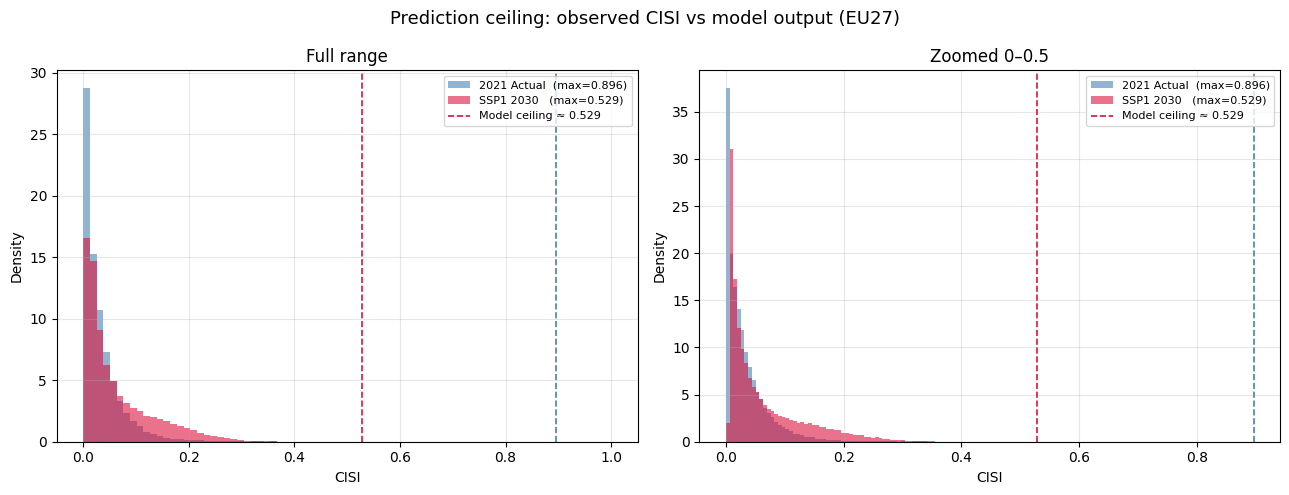

Actual max: 0.8959 | Model max: 0.5289
Actual % > 0.15: 2.16% | Model % > 0.15: 12.44%


In [13]:
# --- Figure 1: Prediction ceiling ---
# Overlaid histogram of 2021 actual CISI vs SSP1 2030 projection (EU27 pixels only)

with rasterio.open(REFERENCE_RASTER) as src:
    actual = src.read(1).astype(np.float32)

actual_vals = actual[VALID_MASK]
actual_vals = actual_vals[~np.isnan(actual_vals)]
pred_vals   = results['SSP1'][2030][VALID_MASK]
pred_vals   = pred_vals[~np.isnan(pred_vals)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Prediction ceiling: observed CISI vs model output (EU27)', fontsize=13)

bins_full  = np.linspace(0, 1.0, 80)
bins_zoom  = np.linspace(0, 0.5, 80)

for ax, bins, title in zip(axes,
                            [bins_full, bins_zoom],
                            ['Full range', 'Zoomed 0–0.5']):
    ax.hist(actual_vals, bins=bins, alpha=0.6, color='steelblue',
            label=f'2021 Actual  (max={actual_vals.max():.3f})', density=True)
    ax.hist(pred_vals,   bins=bins, alpha=0.6, color='crimson',
            label=f'SSP1 2030   (max={pred_vals.max():.3f})', density=True)
    ax.axvline(actual_vals.max(), color='steelblue', linestyle='--', linewidth=1.2)
    ax.axvline(pred_vals.max(),   color='crimson',   linestyle='--', linewidth=1.2,
               label=f'Model ceiling ≈ {pred_vals.max():.3f}')
    ax.set_xlabel('CISI'); ax.set_ylabel('Density')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/diagnostic_prediction_ceiling.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Actual max: {actual_vals.max():.4f} | Model max: {pred_vals.max():.4f}')
print(f'Actual % > 0.15: {(actual_vals > 0.15).mean()*100:.2f}% | Model % > 0.15: {(pred_vals > 0.15).mean()*100:.2f}%')

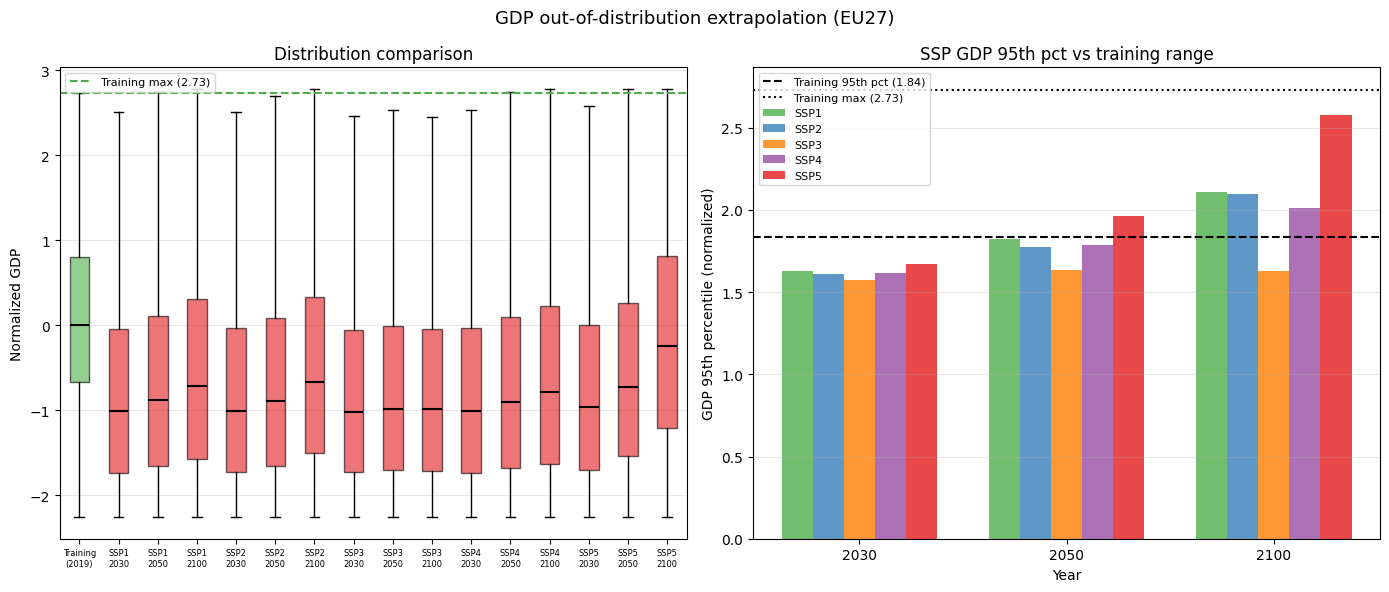

Training GDP   — min: -2.257  max: 2.731  95th: 1.835
SSP1 2030         — min: -2.257  max: 2.784  95th: 1.631
SSP1 2050         — min: -2.257  max: 2.784  95th: 1.823
SSP1 2100         — min: -2.257  max: 2.784  95th: 2.106
SSP2 2030         — min: -2.257  max: 2.784  95th: 1.613
SSP2 2050         — min: -2.257  max: 2.784  95th: 1.777
SSP2 2100         — min: -2.257  max: 2.784  95th: 2.099
SSP3 2030         — min: -2.257  max: 2.784  95th: 1.576
SSP3 2050         — min: -2.257  max: 2.784  95th: 1.635
SSP3 2100         — min: -2.257  max: 2.784  95th: 1.631
SSP4 2030         — min: -2.257  max: 2.784  95th: 1.618
SSP4 2050         — min: -2.257  max: 2.784  95th: 1.787
SSP4 2100         — min: -2.257  max: 2.784  95th: 2.012
SSP5 2030         — min: -2.257  max: 2.784  95th: 1.672
SSP5 2050         — min: -2.257  max: 2.784  95th: 1.965
SSP5 2100         — min: -2.257  max: 2.784  95th: 2.575


In [14]:
# --- Figure 2: GDP out-of-distribution extrapolation ---
# Compare training GDP distribution vs SSP GDP distributions (EU27 pixels)

TRAIN_GDP_PATH = r'READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif'

with rasterio.open(TRAIN_GDP_PATH) as src:
    train_gdp = src.read(1).astype(np.float32)
train_gdp_vals = train_gdp[VALID_MASK]
train_gdp_vals = train_gdp_vals[~np.isnan(train_gdp_vals)]

ssp_gdp = {}
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    ssp_gdp[ssp] = {}
    for year in [2030, 2050, 2100]:
        path = rf'{NORM_DIR}\GDP_{ssp}_{year}_normalized.tif'
        with rasterio.open(path) as src:
            data = src.read(1).astype(np.float32)
        vals = data[VALID_MASK]
        ssp_gdp[ssp][year] = vals[~np.isnan(vals)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('GDP out-of-distribution extrapolation (EU27)', fontsize=13)

# Left: box plot of training range vs SSP distributions
ax = axes[0]
labels = ['Training\n(2019)']
data_boxes = [train_gdp_vals]
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    for year in [2030, 2050, 2100]:
        labels.append(f'{ssp}\n{year}')
        data_boxes.append(ssp_gdp[ssp][year])

bp = ax.boxplot(data_boxes, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=1.5))
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('#4daf4a' if i == 0 else '#e41a1c')
    patch.set_alpha(0.6)

train_max = float(train_gdp_vals.max())
ax.axhline(train_max, color='#4daf4a', linestyle='--', linewidth=1.5,
           label=f'Training max ({train_max:.2f})')
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=6)
ax.set_ylabel('Normalized GDP'); ax.set_title('Distribution comparison')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

# Right: 95th percentile of GDP across SSPs × years vs training max
ax = axes[1]
train_p95 = float(np.percentile(train_gdp_vals, 95))
train_max = float(train_gdp_vals.max())

x = np.arange(3)
width = 0.15
colors_ssp = ['#4daf4a', '#377eb8', '#ff7f00', '#984ea3', '#e41a1c']
for i, ssp in enumerate(['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']):
    p95s = [float(np.percentile(ssp_gdp[ssp][y], 95)) for y in [2030, 2050, 2100]]
    ax.bar(x + i * width, p95s, width, label=ssp, color=colors_ssp[i], alpha=0.8)

ax.axhline(train_p95, color='black', linestyle='--', linewidth=1.5,
           label=f'Training 95th pct ({train_p95:.2f})')
ax.axhline(train_max, color='black', linestyle=':',  linewidth=1.5,
           label=f'Training max ({train_max:.2f})')
ax.set_xticks(x + width * 2)
ax.set_xticklabels([2030, 2050, 2100])
ax.set_xlabel('Year'); ax.set_ylabel('GDP 95th percentile (normalized)')
ax.set_title('SSP GDP 95th pct vs training range')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/diagnostic_gdp_ood.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Training GDP   — min: {train_gdp_vals.min():.3f}  max: {train_gdp_vals.max():.3f}  95th: {train_p95:.3f}')
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    for year in [2030, 2050, 2100]:
        v = ssp_gdp[ssp][year]
        print(f'{ssp} {year}         — min: {v.min():.3f}  max: {v.max():.3f}  95th: {np.percentile(v,95):.3f}')

In [ ]:
# Training ceiling
with rasterio.open(r'READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif') as src:
    _tg = src.read(1).astype(np.float32)
_tv = _tg[VALID_MASK]; _tv = _tv[np.isfinite(_tv)]
TRAIN_GDP_MAX = float(_tv.max())
TRAIN_GDP_MIN = float(_tv.min())

rows = []
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    for year in [2030, 2050, 2100]:
        path = rf'{NORM_DIR}\GDP_{ssp}_{year}_normalized.tif'
        with rasterio.open(path) as src:
            d = src.read(1).astype(np.float32)
        v = d[VALID_MASK]; v = v[np.isfinite(v)]
        n_above = int((v > TRAIN_GDP_MAX).sum())
        pct_above = float((v > TRAIN_GDP_MAX).mean() * 100)
        rows.append({
            'SSP': ssp,
            'Year': year,
            'Min z': round(float(v.min()), 3),
            'Max z': round(float(v.max()), 3),
            'Median z': round(float(np.median(v)), 3),
            'Pixels above ceiling': n_above,
            '% above ceiling': round(pct_above, 1),
        })

df_gdp_ood = pd.DataFrame(rows)

print(f'Training GDP ceiling (max z-score): {TRAIN_GDP_MAX:.3f}')
print(f'Training GDP floor  (min z-score): {TRAIN_GDP_MIN:.3f}')
print()
print(df_gdp_ood.to_string(index=False))
display(df_gdp_ood.style
    .format({'Min z': '{:.3f}', 'Max z': '{:.3f}', 'Median z': '{:.3f}',
             'Pixels above ceiling': '{:,}', '% above ceiling': '{:.1f}%'})
    .background_gradient(subset=['% above ceiling'], cmap='Reds')
    .set_caption(f'GDP OOD extent — training ceiling = {TRAIN_GDP_MAX:.3f} z-score')
)

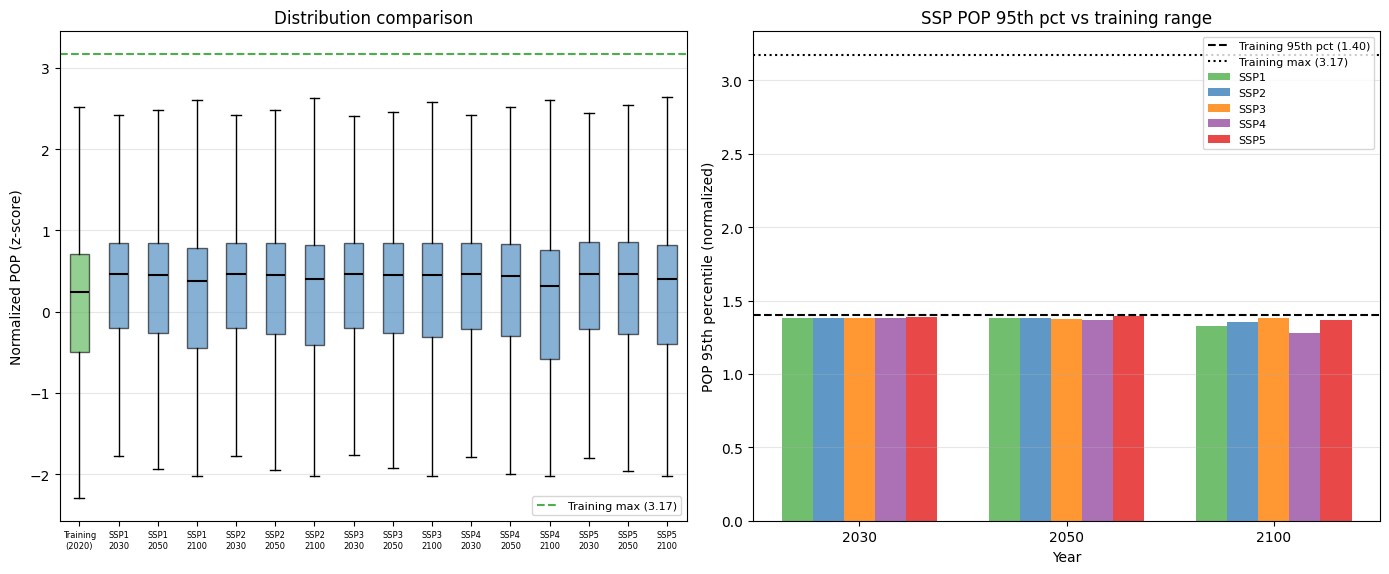

Training POP   — min: -2.973  max: 3.175  95th: 1.400
SSP1 2030         — min: -2.024  max: 2.775  95th: 1.381
SSP1 2050         — min: -2.024  max: 2.793  95th: 1.381
SSP1 2100         — min: -2.024  max: 2.797  95th: 1.323
SSP2 2030         — min: -2.024  max: 2.774  95th: 1.381
SSP2 2050         — min: -2.024  max: 2.793  95th: 1.378
SSP2 2100         — min: -2.024  max: 2.821  95th: 1.351
SSP3 2030         — min: -2.024  max: 2.774  95th: 1.380
SSP3 2050         — min: -2.024  max: 2.796  95th: 1.374
SSP3 2100         — min: -2.024  max: 2.888  95th: 1.383
SSP4 2030         — min: -2.024  max: 2.771  95th: 1.379
SSP4 2050         — min: -2.024  max: 2.774  95th: 1.366
SSP4 2100         — min: -2.024  max: 2.764  95th: 1.280
SSP5 2030         — min: -2.024  max: 2.778  95th: 1.386
SSP5 2050         — min: -2.024  max: 2.806  95th: 1.396
SSP5 2100         — min: -2.024  max: 2.827  95th: 1.369


In [16]:
# --- Figure 2b: POP in-distribution verification ---
# Compare training POP distribution vs SSP POP distributions (EU27 pixels)

TRAIN_POP_PATH_DIAG = r'READY_data\inputs_normalized\2020_pop_aligned_010_normalized.tif'

with rasterio.open(TRAIN_POP_PATH_DIAG) as src:
    train_pop_diag = src.read(1).astype(np.float32)
train_pop_vals = train_pop_diag[VALID_MASK]
train_pop_vals = train_pop_vals[~np.isnan(train_pop_vals)]

ssp_pop = {}
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    ssp_pop[ssp] = {}
    for year in [2030, 2050, 2100]:
        path = rf'{NORM_DIR}\POP_{ssp}_{year}_normalized.tif'
        with rasterio.open(path) as src:
            data = src.read(1).astype(np.float32)
        vals = data[VALID_MASK]
        ssp_pop[ssp][year] = vals[~np.isnan(vals)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('', fontsize=13)

# Left: box plot of training range vs SSP distributions
ax = axes[0]
labels = ['Training\n(2020)']
data_boxes = [train_pop_vals]
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    for year in [2030, 2050, 2100]:
        labels.append(f'{ssp}\n{year}')
        data_boxes.append(ssp_pop[ssp][year])

bp = ax.boxplot(data_boxes, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=1.5))
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('#4daf4a' if i == 0 else '#377eb8')
    patch.set_alpha(0.6)

train_max_pop = float(train_pop_vals.max())
ax.axhline(train_max_pop, color='#4daf4a', linestyle='--', linewidth=1.5,
           label=f'Training max ({train_max_pop:.2f})')
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=6)
ax.set_ylabel('Normalized POP (z-score)'); ax.set_title('Distribution comparison')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

# Right: 95th percentile of POP across SSPs × years vs training max
ax = axes[1]
train_p95_pop = float(np.percentile(train_pop_vals, 95))

x = np.arange(3)
width = 0.15
colors_ssp = ['#4daf4a', '#377eb8', '#ff7f00', '#984ea3', '#e41a1c']
for i, ssp in enumerate(['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']):
    p95s = [float(np.percentile(ssp_pop[ssp][y], 95)) for y in [2030, 2050, 2100]]
    ax.bar(x + i * width, p95s, width, label=ssp, color=colors_ssp[i], alpha=0.8)

ax.axhline(train_p95_pop, color='black', linestyle='--', linewidth=1.5,
           label=f'Training 95th pct ({train_p95_pop:.2f})')
ax.axhline(train_max_pop, color='black', linestyle=':',  linewidth=1.5,
           label=f'Training max ({train_max_pop:.2f})')
ax.set_xticks(x + width * 2)
ax.set_xticklabels([2030, 2050, 2100])
ax.set_xlabel('Year'); ax.set_ylabel('POP 95th percentile (normalized)')
ax.set_title('SSP POP 95th pct vs training range')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/diagnostic_pop_indistribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Training POP   — min: {train_pop_vals.min():.3f}  max: {train_pop_vals.max():.3f}  95th: {train_p95_pop:.3f}')
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    for year in [2030, 2050, 2100]:
        v = ssp_pop[ssp][year]
        print(f'{ssp} {year}         — min: {v.min():.3f}  max: {v.max():.3f}  95th: {np.percentile(v,95):.3f}')

In [ ]:
# --- Figure 3: Scenario indistinguishability ---
# Bar chart of key metrics across 2021 actual + all SSP 2030 projections


metrics = {
    'Mean CISI':    [],
    'Max CISI':     [],
    '% > 0.15':     [],
    'City Mean\n(pixels > 0.15)': [],
}
labels = []

with rasterio.open(REFERENCE_RASTER) as src:
    actual_full = src.read(1).astype(np.float32)

for label, arr in [('2024\nActual', actual_full)] + [(ssp + '\n2030', results[ssp][2030]) for ssp in SSPS]:
    vals = arr[VALID_MASK]
    vals = vals[~np.isnan(vals)]
    city = vals[vals > 0.15]
    metrics['Mean CISI'].append(float(vals.mean()))
    metrics['Max CISI'].append(float(vals.max()))
    metrics['% > 0.15'].append(float((vals > 0.15).mean() * 100))
    metrics['City Mean\n(pixels > 0.15)'].append(float(city.mean()) if len(city) > 0 else 0.0)
    labels.append(label)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('', fontsize=12)

bar_colors = ['#2c7bb6'] + ['#d7191c', '#fdae61', '#abdda4', '#2b83ba', '#762a83']

for ax, (metric, values) in zip(axes, metrics.items()):
    bars = ax.bar(range(len(labels)), values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(metric, fontsize=10)
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/diagnostic_scenario_indistinguishability.png', dpi=150, bbox_inches='tight')
plt.show()

# Print range across SSP scenarios
for metric, values in metrics.items():
    ssp_vals = values[1:]
    print(f'{metric.replace(chr(10)," "):<30}  2021={values[0]:.4f}  '
          f'SSP range=[{min(ssp_vals):.4f}, {max(ssp_vals):.4f}]  '
          f'spread={max(ssp_vals)-min(ssp_vals):.5f}')

## Feature importance analysis

Three complementary methods applied to the 2024 (2021, training-era) EU27 input data:
- **Channel ablation**: zero out one channel group, measure mean absolute prediction change vs baseline
- **Permutation importance**: spatially shuffle one channel group (×3 repeats, averaged), measure prediction change
- **Gradient saliency**: mean |∂output/∂input| per channel via backpropagation

Channel layout: 0=GDP, 1=POP, 2–8=LC classes (Water, Forest, Grassland, Barren, Cropland, Urban, Snow/Ice)

In [18]:
# Load 2021 (training-era) input stack
TRAIN_GDP_PATH = r'READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif'
TRAIN_POP_PATH = r'READY_data\inputs_normalized\2020_pop_aligned_010_normalized.tif'
TRAIN_LC_PATH  = r'READY_data\landuse_onehot\chen2015_lc_onehot.tif'

with rasterio.open(TRAIN_GDP_PATH) as src:
    gdp_2024 = src.read(1).astype(np.float32)
with rasterio.open(TRAIN_POP_PATH) as src:
    pop_2024 = src.read(1).astype(np.float32)
with rasterio.open(TRAIN_LC_PATH) as src:
    lc_2024 = src.read().astype(np.float32)  # (n_lc_bands, H, W)

print(f'GDP: {gdp_2024.shape}  POP: {pop_2024.shape}  LC: {lc_2024.shape}')

input_stack_2024 = np.concatenate([
    gdp_2024[np.newaxis],
    pop_2024[np.newaxis],
    lc_2024,
], axis=0)
input_stack_2024 = fill_input_stack(input_stack_2024)
print(f'Full input stack: {input_stack_2024.shape}  (channels: GDP, POP, LC×{lc_2024.shape[0]})')

baseline_pred = predict_raster(input_stack_2024)
baseline_vals = baseline_pred[VALID_MASK]
print(f'Baseline — mean: {np.nanmean(baseline_vals):.4f}  max: {np.nanmax(baseline_vals):.4f}')

GDP: (485, 570)  POP: (485, 570)  LC: (7, 485, 570)
Full input stack: (9, 485, 570)  (channels: GDP, POP, LC×7)
Baseline — mean: 0.0840  max: 0.6038


# Channel ablation + permutation importance


In [ ]:
n_lc = lc_2024.shape[0]
LC_NAMES = ['Water', 'Forest', 'Grassland', 'Barren', 'Cropland', 'Urban', 'Snow/Ice'][:n_lc]

CH_GROUPS = {'GDP': [0], 'POP': [1], 'LC (all)': list(range(2, 2 + n_lc))}
for i, name in enumerate(LC_NAMES):
    CH_GROUPS[f'LC-{name}'] = [2 + i]

N_PERMS = 3
np.random.seed(42)

ablation_scores    = {}
permutation_scores = {}

base = baseline_pred[VALID_MASK]

for group, channels in CH_GROUPS.items():
    print(f'{group}...', end=' ', flush=True)

    # Ablation
    s = input_stack_2024.copy()
    for c in channels:
        s[c] = 0.0
    abl_vals = predict_raster(s)[VALID_MASK]
    ablation_scores[group] = float(np.nanmean(np.abs(base - abl_vals)))

    # Permutation
    diffs = []
    for _ in range(N_PERMS):
        s = input_stack_2024.copy()
        for c in channels:
            flat = s[c].flatten()
            np.random.shuffle(flat)
            s[c] = flat.reshape(s[c].shape)
        perm_vals = predict_raster(s)[VALID_MASK]
        diffs.append(float(np.nanmean(np.abs(base - perm_vals))))
    permutation_scores[group] = float(np.mean(diffs))

    print(f'ablation={ablation_scores[group]:.5f}  permutation={permutation_scores[group]:.5f}')

print('\nDone.')

In [20]:
# Gradient-based saliency — mean |∂output/∂input| per channel
H, W   = REF_SHAPE
valid_idx = np.argwhere(VALID_MASK)

all_patches = []
for i, j in valid_idx:
    pad_top    = max(0, HALF - i);    pad_bottom = max(0, (i + HALF) - H)
    pad_left   = max(0, HALF - j);    pad_right  = max(0, (j + HALF) - W)
    i0 = max(0, i - HALF);            i1 = min(H, i + HALF)
    j0 = max(0, j - HALF);            j1 = min(W, j + HALF)
    patch = input_stack_2024[:, i0:i1, j0:j1].copy()
    if pad_top or pad_bottom or pad_left or pad_right:
        patch = np.pad(patch, ((0,0),(pad_top,pad_bottom),(pad_left,pad_right)), mode='edge')
    all_patches.append(patch)

n_ch = input_stack_2024.shape[0]
channel_grads = np.zeros(n_ch, dtype=np.float64)
BATCH = 512

projection_model.eval()
for start in range(0, len(all_patches), BATCH):
    batch_np = np.stack(all_patches[start:start + BATCH])
    batch    = torch.FloatTensor(batch_np).to(device)
    batch.requires_grad_(True)
    out = projection_model(batch)
    out.mean().backward()
    grads = batch.grad.detach().abs().mean(dim=(0, 2, 3)).cpu().numpy()
    channel_grads += grads * len(batch_np)

channel_grads /= len(all_patches)

saliency_scores = {'GDP': float(channel_grads[0]), 'POP': float(channel_grads[1]),
                   'LC (all)': float(channel_grads[2:].mean())}
for i, name in enumerate(LC_NAMES):
    saliency_scores[f'LC-{name}'] = float(channel_grads[2 + i])

print('Gradient saliency (mean |∂output/∂input|):')
for k, v in saliency_scores.items():
    print(f'  {k:<15}: {v:.6f}')

Gradient saliency (mean |∂output/∂input|):
  GDP            : 0.000005
  POP            : 0.000006
  LC (all)       : 0.000003
  LC-Water       : 0.000003
  LC-Forest      : 0.000005
  LC-Grassland   : 0.000004
  LC-Barren      : 0.000003
  LC-Cropland    : 0.000004
  LC-Urban       : 0.000004
  LC-Snow/Ice    : 0.000000


In [ ]:
# Summary figure — all three methods side by side

groups_all = ['GDP', 'POP', 'LC (all)'] + [f'LC-{n}' for n in LC_NAMES]

df_fi = pd.DataFrame({
    'Channel':     groups_all,
    'Ablation':    [ablation_scores[g]    for g in groups_all],
    'Permutation': [permutation_scores[g] for g in groups_all],
    'Gradient':    [saliency_scores[g]    for g in groups_all],
})
for col in ['Ablation', 'Permutation', 'Gradient']:
    df_fi[col + '_n'] = df_fi[col] / df_fi[col].max()

# Print with scientific notation so small gradient values are visible
print(df_fi[['Channel', 'Ablation', 'Permutation', 'Gradient']].to_string(
    index=False, float_format=lambda x: f'{x:.4e}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature importance — 2021 EU27 inputs', fontsize=13)

x_all  = np.arange(len(groups_all))
x_top  = np.arange(3)
w = 0.26

for ax, x, groups, title in [
    (axes[0], x_all, groups_all, 'All channels (normalized)'),
    (axes[1], x_top, ['GDP', 'POP', 'LC (all)'], 'GDP vs POP vs LC'),
]:
    df_sub = df_fi[df_fi['Channel'].isin(groups)].set_index('Channel').loc[groups]
    ax.bar(x - w, df_sub['Ablation_n'],    w, label='Ablation',    color='steelblue',  alpha=0.85)
    ax.bar(x,     df_sub['Permutation_n'], w, label='Permutation', color='darkorange', alpha=0.85)
    ax.bar(x + w, df_sub['Gradient_n'],    w, label='Gradient',    color='seagreen',   alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('Normalized importance (0–1)')
    ax.set_title(title); ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Top 10 Highest CISI Pixels — 2021 vs SSP 2030

The 10 EU27 pixels with the highest observed 2021 CISI, with the model's SSP 2030 prediction for each scenario at those same locations. Shows whether the most critical infrastructure nodes are stable or shifting across scenarios.

In [ ]:
with rasterio.open(REFERENCE_RASTER) as src:
    cisi_2024 = src.read(1).astype(np.float32)
    transform = src.transform

# Top 10 EU27 pixels by 2021 CISI
rows_idx, cols_idx = np.where(VALID_MASK & np.isfinite(cisi_2024))
vals_2024 = cisi_2024[rows_idx, cols_idx]
top_order = np.argsort(vals_2024)[-10:][::-1]
top_rows  = rows_idx[top_order]
top_cols  = cols_idx[top_order]

# Pixel centre coordinates (lon, lat)
lons = [rasterio_xy(transform, int(r), int(c))[0] for r, c in zip(top_rows, top_cols)]
lats = [rasterio_xy(transform, int(r), int(c))[1] for r, c in zip(top_rows, top_cols)]

# Country lookup via point-in-polygon
pts_gdf = gpd.GeoDataFrame(
    {'idx': range(10)},
    geometry=[Point(lon, lat) for lon, lat in zip(lons, lats)],
    crs='EPSG:4326',
)
joined = pts_gdf.sjoin(world[['NAME', 'geometry']], how='left', predicate='within')
country_map = joined.groupby('idx')['NAME'].first()
countries = [str(country_map.get(i, 'Unknown')) for i in range(10)]

# Build table
records = []
for rank, (r, c, lon, lat, country) in enumerate(
        zip(top_rows, top_cols, lons, lats, countries), 1):
    rec = {
        'Rank':        rank,
        'Country':     country,
        'Lat':         round(lat, 2),
        'Lon':         round(lon, 2),
        '2024 Actual': round(float(cisi_2024[r, c]), 4),
    }
    for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
        rec[ssp + ' 2030'] = round(float(results[ssp][2030][r, c]), 4)
    records.append(rec)

df_top10 = pd.DataFrame(records).set_index('Rank')
print('Top 10 pixels by 2021 CISI — SSP 2030 model predictions at same locations\n')
print(df_top10.to_string())

ssp_cols = [s + ' 2030' for s in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']]
display(df_top10.style
    .background_gradient(subset=['2021 Actual'], cmap='YlOrRd', vmin=0, vmax=1)
    .background_gradient(subset=ssp_cols,        cmap='YlOrRd', vmin=0, vmax=0.35)
    .format({**{'2021 Actual': '{:.4f}'}, **{s: '{:.4f}' for s in ssp_cols}})
    .set_caption('Top 10 pixels by 2021 CISI — comparison with uncalibrated SSP 2030 projections')
)

# Results

Thesis write-up figures. Run all setup cells above first (model load → inference → `load_results_from_tifs`).

## Figure 1: EU27 CISI — SSP5 2100 Projection

Absolute CISI under the highest-emission scenario at end-of-century. Shows *where* infrastructure criticality risk concentrates under worst-case conditions.

In [ ]:
FS = 13

world = gpd.read_file(SHP_PATH)

with rasterio.open(f'{OUTPUT_DIR}/cisi_pred_SSP5_2100.tif') as src:
    cisi_ssp5 = src.read(1).astype(np.float32)
    bounds    = src.bounds

cisi_map = np.where(VALID_MASK, cisi_ssp5, np.nan)
ext = [bounds.left, bounds.right, bounds.bottom, bounds.top]

fig, ax = plt.subplots(figsize=(10, 7))

im = ax.imshow(cisi_map, cmap='YlOrRd', vmin=0, vmax=0.5,
               extent=ext, origin='upper', aspect='auto')
world.boundary.plot(ax=ax, linewidth=0.4, color='black')
ax.set_xlim(bounds.left, bounds.right)
ax.set_ylim(bounds.bottom, bounds.top)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('CISI', fontsize=FS)
cbar.ax.tick_params(labelsize=FS - 1)

ax.set_title('EU27 CISI — SSP5 2100 Projection', fontsize=FS)
ax.set_xlabel('Longitude', fontsize=FS)
ax.set_ylabel('Latitude', fontsize=FS)
ax.tick_params(labelsize=FS - 1)

fig.tight_layout()
out = f'{FIGURES_DIR}/cisi_map_ssp5_2100.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved {out}')
plt.show()


In [ ]:
# Setup variables for Randstad spot-check

# Coordinate grids
with rasterio.open(REFERENCE_RASTER) as _src:
    _tf = _src.transform
    _h, _w = _src.height, _src.width
    hist_cisi = _src.read(1).astype(np.float32)
rows_g, cols_g = np.meshgrid(np.arange(_h), np.arange(_w), indexing='ij')
lon = _tf.c + (cols_g + 0.5) * _tf.a
lat = _tf.f + (rows_g + 0.5) * _tf.e

# EU27 mask
mask = VALID_MASK

# SSP5-2100 prediction (most extreme scenario — matches Figure 1 in Results)
pred = results['SSP5'][2100].astype(np.float32)

# coastal: pixels with at least one NaN GDP neighbour (3×3 kernel on training GDP)
with rasterio.open(r'READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif') as _gs:
    _gdp = _gs.read(1).astype(np.float32)
_nan_gdp = np.isnan(_gdp).astype(float)
_neighbor_nan = generic_filter(_nan_gdp, np.max, size=3, mode='constant', cval=0)
coastal = (_neighbor_nan > 0) & mask


## Figure 2: EU27 CISI Trajectory — Observed vs Projected

Mean EU27 CISI per SSP scenario across 2030, 2050, 2100, anchored to the 2021 observed value.

In [ ]:
SSP_COLORS  = {'SSP1': '#1b7837', 'SSP2': '#2166ac', 'SSP3': '#d73027',
               'SSP4': '#f1a340', 'SSP5': '#762a83'}
SSP_MARKERS = {'SSP1': 'o', 'SSP2': 's', 'SSP3': '^', 'SSP4': 'D', 'SSP5': 'p'}
FS = 13

# 2021 observed baseline
with rasterio.open(REFERENCE_RASTER) as src:
    _cisi_obs = src.read(1).astype(np.float32)
_cisi_obs_masked = np.where(VALID_MASK, _cisi_obs, np.nan)

# Fixed city mask based on observed 2021 CISI
CITY_MASK = VALID_MASK & (_cisi_obs > 0.15)

cisi_obs_mean      = 0.034
cisi_obs_city_mean = 0.2195

# Projected means per SSP per year
YEARS_PROJ = [2030, 2050, 2100]
proj_means      = {}
proj_city_means = {}
for ssp in SSPS:
    proj_means[ssp]      = []
    proj_city_means[ssp] = []
    for year in YEARS_PROJ:
        if year in results.get(ssp, {}):
            data = results[ssp][year]
            proj_means[ssp].append(float(np.nanmean(data[VALID_MASK])))
            proj_city_means[ssp].append(float(np.nanmean(data[CITY_MASK])))
        else:
            proj_means[ssp].append(np.nan)
            proj_city_means[ssp].append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, means, obs_mean, ylabel, title in [
    (axes[0], proj_means,      cisi_obs_mean,      'Mean CISI (EU27 land pixels)',       'Global mean'),
    (axes[1], proj_city_means, cisi_obs_city_mean, 'Mean CISI (city pixels, CISI>0.15)', 'City mean'),
]:
    for ssp in SSPS:
        ax.plot(YEARS_PROJ, means[ssp],
                color=SSP_COLORS[ssp], marker=SSP_MARKERS[ssp],
                markersize=5, linewidth=1.8, linestyle=':', label=ssp)
    ax.plot(2021, obs_mean,
            marker='o', markersize=9, color='black', zorder=5, linestyle='none',
            label='2021 observed (uncalibrated)')
    ax.set_xlabel('Year', fontsize=FS)
    ax.set_ylabel(ylabel, fontsize=FS)
    ax.set_title(title, fontsize=FS)
    ax.set_xticks([2021] + YEARS_PROJ)
    ax.set_xticklabels(['2021', '2030', '2050', '2100'], fontsize=FS)
    ax.tick_params(axis='y', labelsize=FS)
    ax.legend(fontsize=FS - 1, frameon=False)
    ax.grid(True, alpha=0.2)

fig.tight_layout()
out = f'{FIGURES_DIR}/cisi_trajectory.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved {out}')
plt.show()


## Figure 3: CISI Change by 2100 — SSP Comparison (Δ vs mean SSP-2030 baseline)

Divergent maps of projected CISI change per SSP scenario at 2100, relative to the pixel-wise mean of the five SSP-2030 predictions. Red = increase, blue = decrease. Colorscale ±0.13.

In [ ]:
FS   = 13
SSPS = ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']
VABS = 0.13

with rasterio.open(r'READY_data\labels\eu_mask_010deg.tif') as src:
    VALID_MASK_D = src.read(1).astype(bool)
with rasterio.open(r'READY_data\labels\CISI_010deg.tif') as src:
    _hist = src.read(1).astype(np.float32)
    bounds = src.bounds
_hist[~VALID_MASK_D] = np.nan

world = gpd.read_file(SHP_PATH)
ext = [bounds.left, bounds.right, bounds.bottom, bounds.top]

cmap_div = plt.get_cmap('RdBu_r')
norm_div  = mcolors.TwoSlopeNorm(vmin=-VABS, vcenter=0, vmax=VABS)

fig, axes = plt.subplots(3, 2, figsize=(12, 14))

for idx, ssp in enumerate(SSPS):
    row, col = divmod(idx, 2)
    ax = axes[row][col]

    pred = results[ssp][2100].copy()
    pred[~VALID_MASK_D] = np.nan
    delta = pred - _hist
    mean_d = float(np.nanmean(delta))

    im = ax.imshow(delta, cmap=cmap_div, norm=norm_div,
                   extent=ext, origin='upper', aspect='auto')
    world.boundary.plot(ax=ax, linewidth=0.4, color='black')
    ax.set_xlim(bounds.left, bounds.right)
    ax.set_ylim(bounds.bottom, bounds.top)
    sign = '+' if mean_d >= 0 else ''
    ax.set_title(f"{ssp}  (mean {sign}{mean_d:.4f})", fontsize=FS)
    ax.tick_params(labelsize=FS - 2)

axes[2][1].axis('off')
cbar_ax = fig.add_axes([0.55, 0.08, 0.38, 0.025])
sm = plt.cm.ScalarMappable(cmap=cmap_div, norm=norm_div)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('ΔCISI vs historic CISI', fontsize=FS)
cbar.ax.tick_params(labelsize=FS - 1)

fig.tight_layout(rect=[0, 0.07, 1, 1])
out = f'{FIGURES_DIR}/cisi_delta_2100.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved {out}')
plt.show()


## Historic CISI vs projected ΔCISI

In [ ]:
FS        = 13
VABS      = 0.13
SSP_SHOW  = 'SSP5'
YEAR_SHOW = 2100

with rasterio.open(r'READY_data\labels\eu_mask_010deg.tif') as s:
    _eu = s.read(1).astype(bool)
with rasterio.open(r'READY_data\labels\CISI_010deg.tif') as s:
    _cisi_hist = s.read(1).astype(np.float32)
    nd = s.nodata; bounds = s.bounds
if nd is not None:
    _cisi_hist = np.where(_cisi_hist == nd, np.nan, _cisi_hist)
_cisi_hist = np.where(_eu, _cisi_hist, np.nan)
HIST_MEAN  = float(np.nanmean(_cisi_hist))

pred = results[SSP_SHOW][YEAR_SHOW].copy()
pred[~_eu] = np.nan
_delta = pred - _cisi_hist
DELTA_MEAN = float(np.nanmean(_delta))
DELTA_PCT  = DELTA_MEAN / HIST_MEAN * 100

world = gpd.read_file(SHP_PATH)
ext   = [bounds.left, bounds.right, bounds.bottom, bounds.top]

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 6))

im_h = ax_l.imshow(_cisi_hist, cmap='YlOrRd', vmin=0, vmax=0.5,
                   extent=ext, origin='upper', aspect='auto')
world.boundary.plot(ax=ax_l, linewidth=0.4, color='black')
ax_l.set_xlim(bounds.left, bounds.right); ax_l.set_ylim(bounds.bottom, bounds.top)
ax_l.set_title(f'Historic CISI  (mean = {HIST_MEAN:.4f})', fontsize=FS)
ax_l.tick_params(labelsize=FS - 2)
cb_h = plt.colorbar(im_h, ax=ax_l, fraction=0.03)
cb_h.set_label('CISI', fontsize=FS); cb_h.ax.tick_params(labelsize=FS - 1)

norm_div = mcolors.TwoSlopeNorm(vmin=-VABS, vcenter=0, vmax=VABS)
im_d = ax_r.imshow(_delta, cmap='RdBu_r', norm=norm_div,
                   extent=ext, origin='upper', aspect='auto')
world.boundary.plot(ax=ax_r, linewidth=0.4, color='black')
ax_r.set_xlim(bounds.left, bounds.right); ax_r.set_ylim(bounds.bottom, bounds.top)
sign = '+' if DELTA_MEAN >= 0 else ''
ax_r.set_title(
    f'{SSP_SHOW} {YEAR_SHOW} \u0394CISI  (mean {sign}{DELTA_MEAN:.4f} = {sign}{DELTA_PCT:.1f}% of historic)',
    fontsize=FS)
ax_r.tick_params(labelsize=FS - 2)
cb_d = plt.colorbar(im_d, ax=ax_r, fraction=0.03)
cb_d.set_label('\u0394CISI', fontsize=FS); cb_d.ax.tick_params(labelsize=FS - 1)

fig.tight_layout()
out = f'{FIGURES_DIR}/historic_vs_delta_{SSP_SHOW}_{YEAR_SHOW}.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved {out}')
plt.show()


## Figure 4: EU27 Land Cover Composition — Historical vs Projected

Stacked bar charts of LC class shares per SSP scenario across 2021, 2030, 2050, 2100.

In [ ]:
LC_NAMES  = ['Water', 'Forest', 'Grassland', 'Barren', 'Cropland', 'Urban', 'Snow/Ice']
LC_COLORS = ['#4393c3', '#1a9641', '#a8ddb5', '#d9b382', '#f7c59f', '#d7191c', '#e0e0e0']
SSPS_LC   = ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']
YEARS_LC  = [2030, 2050, 2100]

# EU27 mask
with rasterio.open(r'READY_data\labels\eu_mask_010deg.tif') as src:
    eu27_lc = src.read(1).astype(bool)
n_eu = int(eu27_lc.sum())

# Historical LC percentages (from training onehot file)
hist_pct = []
with rasterio.open(r'READY_data\landuse_onehot\chen2015_lc_onehot.tif') as src:
    h = src.read().astype(np.float32)
for i in range(7):
    hist_pct.append(100 * float((h[i][eu27_lc] > 0).sum()) / n_eu)

# SSP LC percentages
ssp_pct = {}
for ssp in SSPS_LC:
    ssp_pct[ssp] = {}
    for year in YEARS_LC:
        pcts = []
        for cls in range(1, 8):
            path = rf'READY_data\inputs_normalized\ssp\LC_{ssp}_{year}_class_{cls}.tif'
            with rasterio.open(path) as src:
                data = src.read(1).astype(np.float32)
            pcts.append(100 * float(np.nansum(data[eu27_lc] > 0)) / n_eu)
        ssp_pct[ssp][year] = pcts

# Figure: 3 rows x 2 cols, last panel = legend
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle('EU27 Land Cover Composition — Historical vs Projected', fontsize=13)

x_labels = ['Hist. 2020'] + [str(y) for y in YEARS_LC]
x     = np.arange(len(x_labels))
bar_w = 0.7

for idx, ssp in enumerate(SSPS_LC):
    row, col = divmod(idx, 2)
    ax = axes[row][col]
    all_pcts = [hist_pct] + [ssp_pct[ssp][y] for y in YEARS_LC]
    bottoms = np.zeros(len(all_pcts))
    for ci in range(7):
        vals = np.array([all_pcts[t][ci] for t in range(len(all_pcts))])
        ax.bar(x, vals, bar_w, bottom=bottoms, color=LC_COLORS[ci])
        bottoms += vals
    ax.set_title(ssp, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel('% of EU27 pixels')
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))

# Legend in empty 6th panel
axes[2][1].axis('off')
handles = [mpatches.Patch(color=LC_COLORS[i], label=LC_NAMES[i]) for i in range(7)]
axes[2][1].legend(handles=handles, loc='center', fontsize=11, frameon=False,
                  title='LC class', title_fontsize=12)

plt.tight_layout()
out = f'{FIGURES_DIR}/lc_composition_over_time.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved {out}')
plt.show()


## Figure 5: EU27 GDP and Population — Historical vs Projected

Absolute EU27 totals per SSP scenario from historical baseline to 2100.

In [ ]:
POP_MU = 7.0373; POP_STD = 2.3674
SSPS_GP  = ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']
YEARS_GP = [2030, 2050, 2100]

SSP_COLORS = {
    'SSP1': '#1b7837',
    'SSP2': '#2166ac',
    'SSP3': '#d73027',
    'SSP4': '#f1a340',
    'SSP5': '#762a83',
}
SSP_MARKERS = {
    'SSP1': 'o',
    'SSP2': 's',
    'SSP3': '^',
    'SSP4': 'D',
    'SSP5': 'p',
}
FS = 13  # base font size for axes

with rasterio.open(r'READY_data\labels\eu_mask_010deg.tif') as src:
    eu27_gp = src.read(1).astype(bool)

# ── Historical baselines ───────────────────────────────────────────────────────
with rasterio.open(r'READY_data\inputs\2019_gdp_aligned_010.tif') as src:
    g = src.read(1).astype(np.float64)
g[~np.isfinite(g)] = np.nan
gdp_hist = float(np.nansum(g[eu27_gp & (g > 0)])) / 1e6

with rasterio.open(r'READY_data\inputs\2020_pop_aligned_010.tif') as src:
    p = src.read(1).astype(np.float64)
p[~np.isfinite(p)] = np.nan; p[p < 0] = np.nan
pop_hist = float(np.nansum(p[eu27_gp & np.isfinite(p)])) / 1e6

# ── SSP totals ────────────────────────────────────────────────────────────────
gdp_totals = {}
pop_totals = {}
for ssp in SSPS_GP:
    gdp_totals[ssp] = []
    pop_totals[ssp] = []
    for year in YEARS_GP:
        with rasterio.open(rf'READY_data\inputs_converted\ssp\GDP_{ssp}_{year}_converted.tif') as src:
            d = src.read(1).astype(np.float64)
        d[~np.isfinite(d)] = np.nan
        gdp_totals[ssp].append(float(np.nansum(d[eu27_gp & np.isfinite(d) & (d > 0)])) / 1e6)

        with rasterio.open(rf'READY_data\inputs_normalized\ssp\POP_{ssp}_{year}_normalized.tif') as src:
            z = src.read(1).astype(np.float64)
        raw = np.expm1(z * POP_STD + POP_MU)
        raw[~np.isfinite(raw)] = np.nan; raw[raw < 0] = np.nan
        pop_totals[ssp].append(float(np.nansum(raw[eu27_gp & np.isfinite(raw)])) / 1e6)

gdp_max  = max(max(v) for v in gdp_totals.values())
pop_max  = max(max(v) for v in pop_totals.values())
pop_min  = 295

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 5))

gs_outer = gridspec.GridSpec(1, 2, figure=fig)
ax1 = fig.add_subplot(gs_outer[0])

gs_pop = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=gs_outer[1],
    height_ratios=[12, 1], hspace=0.06
)
ax2_top = fig.add_subplot(gs_pop[0])
ax2_bot = fig.add_subplot(gs_pop[1])

gdp_x = [2019] + YEARS_GP
pop_x  = [2020] + YEARS_GP

# ── GDP panel ─────────────────────────────────────────────────────────────────
for ssp in SSPS_GP:
    ax1.plot(gdp_x, [gdp_hist] + gdp_totals[ssp],
             color=SSP_COLORS[ssp], linewidth=2, marker=SSP_MARKERS[ssp],
             markersize=5, linestyle=':', label=ssp)
ax1.plot(2019, gdp_hist, marker='o', markersize=9, color='black', zorder=5, linestyle='none')
ax1.set_title('Total EU27 GDP (trillion USD)', fontsize=FS)
ax1.set_xlabel('Year', fontsize=FS)
ax1.set_ylabel('Total GDP (T USD)', fontsize=FS)
ax1.set_xticks(gdp_x)
ax1.set_xticklabels(['2019\n(hist.)', '2030', '2050', '2100'], fontsize=FS)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f} T'))
ax1.tick_params(axis='y', labelsize=FS)
ax1.legend(fontsize=FS - 1, frameon=False)
ax1.set_ylim(0, gdp_max * 1.18)

# ── POP top strip ─────────────────────────────────────────────────────────────
for ssp in SSPS_GP:
    ax2_top.plot(pop_x, [pop_hist] + pop_totals[ssp],
                 color=SSP_COLORS[ssp], linewidth=2, marker=SSP_MARKERS[ssp],
                 markersize=5, linestyle=':', label=ssp)
ax2_top.plot(2020, pop_hist, marker='o', markersize=9, color='black', zorder=5, linestyle='none')
ax2_top.set_ylim(pop_min, pop_max * 1.18)
ax2_top.set_xticks(pop_x)
ax2_top.set_xticklabels([])
ax2_top.set_title('Total EU27 Population (millions)', fontsize=FS)
ax2_top.set_ylabel('Population (M)', fontsize=FS)
ax2_top.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f} M'))
ax2_top.tick_params(axis='y', labelsize=FS)
ax2_top.legend(fontsize=FS - 1, frameon=False)
ax2_top.spines['bottom'].set_visible(False)
ax2_top.tick_params(bottom=False)

# ── POP bottom zero strip ─────────────────────────────────────────────────────
ax2_bot.set_ylim(0, 1)
ax2_bot.set_yticks([0])
ax2_bot.set_yticklabels(['0 M'], fontsize=FS)
ax2_bot.set_xticks(pop_x)
ax2_bot.set_xticklabels(['2020\n(hist.)', '2030', '2050', '2100'], fontsize=FS)
ax2_bot.set_xlabel('Year', fontsize=FS)
ax2_bot.spines['top'].set_visible(False)
ax2_bot.tick_params(top=False)
ax2_bot.set_xlim(ax2_top.get_xlim())

# ── Break marks ───────────────────────────────────────────────────────────────
d = 0.018
kw  = dict(transform=ax2_top.transAxes, color='k', clip_on=False, linewidth=1.2)
ax2_top.plot((-d, +d), (-d, +d), **kw)
ax2_top.plot((1-d, 1+d), (-d, +d), **kw)
kw2 = dict(transform=ax2_bot.transAxes, color='k', clip_on=False, linewidth=1.2)
ax2_bot.plot((-d, +d), (1-d, 1+d), **kw2)
ax2_bot.plot((1-d, 1+d), (1-d, 1+d), **kw2)

plt.tight_layout()
out = f'{FIGURES_DIR}/gdp_pop_absolute_overview.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved {out}')
plt.show()


## Figure 6: EU27 Urban Land Cover Expansion

Projected share of urban pixels (class 6) per SSP scenario from 2021 to 2100.

In [ ]:
SSP_COLORS = {
    'SSP1': '#1b7837',
    'SSP2': '#2166ac',
    'SSP3': '#d73027',
    'SSP4': '#f1a340',
    'SSP5': '#762a83',
}
SSP_MARKERS = {'SSP1': 'o', 'SSP2': 's', 'SSP3': '^', 'SSP4': 'D', 'SSP5': 'p'}
FS = 13

years = [2015, 2030, 2050, 2100]
data = {
    'SSP1': [1.79, 2.13, 2.47, 2.56],
    'SSP2': [1.79, 2.05, 2.31, 2.37],
    'SSP3': [1.79, 1.92, 1.92, 1.92],
    'SSP4': [1.79, 2.05, 2.24, 2.24],
    'SSP5': [1.79, 2.22, 2.78, 3.48],
}

_ymax = max(v for vals in data.values() for v in vals)
Y_TOP_MIN = 1.75   # top strip starts here (just below 1.79)

fig = plt.figure(figsize=(7, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1], hspace=0.06)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1])

for (k, v), m in zip(data.items(), SSP_MARKERS.items()):
    ax_top.plot(years, v, marker=m[1], label=k, linewidth=1.8,
                color=SSP_COLORS[k], linestyle=':', markersize=5)

ax_top.plot(2015, 1.79, marker='o', markersize=9, color='black', zorder=5, linestyle='none')

ax_top.set_ylim(Y_TOP_MIN, _ymax * 1.18)
ax_top.set_xticks(years)
ax_top.set_xticklabels([])
ax_top.set_ylabel('Urban land (% of EU27)', fontsize=FS)
ax_top.tick_params(axis='y', labelsize=FS)
ax_top.legend(frameon=False, loc='upper left', fontsize=FS - 1)
ax_top.grid(True, alpha=0.2)
ax_top.spines['bottom'].set_visible(False)
ax_top.tick_params(bottom=False)

# Bottom strip: just shows 0 %
ax_bot.set_ylim(0, 1)
ax_bot.set_yticks([0])
ax_bot.set_yticklabels(['0 %'], fontsize=FS)
ax_bot.set_xticks(years)
ax_bot.set_xticklabels(['2015\n(obs.)', '2030', '2050', '2100'], fontsize=FS)
ax_bot.set_xlabel('Year', fontsize=FS)
ax_bot.spines['top'].set_visible(False)
ax_bot.tick_params(top=False)
ax_bot.set_xlim(ax_top.get_xlim())
ax_bot.grid(True, alpha=0.2)

# Break marks
d = 0.018
kw  = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=1.2)
ax_top.plot((-d, +d), (-d, +d), **kw)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kw)
kw2 = dict(transform=ax_bot.transAxes, color='k', clip_on=False, linewidth=1.2)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kw2)
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kw2)

fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/urban_expansion.png', dpi=150, bbox_inches='tight')
print(f'Saved {FIGURES_DIR}/urban_expansion.png')
plt.show()


# Compare results to regression

BELOW this box.

## Delta summary table
For each SSP × year, percentage of EU27 pixels with increasing / decreasing CISI relative to the 2030 baseline, plus mean, max and min change.

In [ ]:
_SSPS  = ['SSP1','SSP2','SSP3','SSP4','SSP5']
_YEARS = [2030, 2050, 2100]

with rasterio.open(r'READY_data\labels\eu_mask_010deg.tif') as s:
    _mask = s.read(1).astype(bool)
with rasterio.open(r'READY_data\labels\CISI_010deg.tif') as s:
    _ch = s.read(1).astype(np.float32); nd = s.nodata
if nd is not None:
    _ch = np.where(_ch == nd, np.nan, _ch)
_hist_eu = np.where(_mask, _ch, np.nan)
HIST_MEAN = float(np.nanmean(_hist_eu))
print(f'Historic CISI mean (EU27): {HIST_MEAN:.4f}')
print()

rows = []
for ssp in _SSPS:
    for year in _YEARS:
        pred = results[ssp][year].copy()
        pred[~_mask] = np.nan
        vals = (pred - _hist_eu)[_mask]
        vals = vals[~np.isnan(vals)]; n = len(vals)
        mean_d = float(vals.mean())
        rows.append({
            'SSP':           ssp,
            'Year':          year,
            'N pixels':      n,
            '% increasing':  round(100 * (vals >  1e-6).sum() / n, 1),
            '% decreasing':  round(100 * (vals < -1e-6).sum() / n, 1),
            'mean delta':    round(mean_d, 4),
            'max delta':     round(float(vals.max()), 4),
            'min delta':     round(float(vals.min()), 4),
            'delta/hist %':  round(mean_d / HIST_MEAN * 100, 2),
        })

df = pd.DataFrame(rows)

hdr = f'{"SSP":<6}{"Year":<6}{"% incr":>8}{"% decr":>8}{"mean d":>10}{"max d":>10}{"min d":>10}{"d/hist%":>10}'
print(hdr)
print('-' * 70)
for _, r in df.iterrows():
    sign = '+' if r['mean delta'] >= 0 else ''
    print(f'{r["SSP"]:<6}{int(r["Year"]):<6}{r["% increasing"]:>8.1f}{r["% decreasing"]:>8.1f}'
          f'{r["mean delta"]:>10.4f}{r["max delta"]:>10.4f}{r["min delta"]:>10.4f}  {sign}{r["delta/hist %"]:>6.1f}%')
df


## GDP growth vs urban land cover expansion

In [ ]:
FS = 13
SSP_COLORS  = {'SSP1': '#1b7837', 'SSP2': '#2166ac', 'SSP3': '#d73027',
               'SSP4': '#f1a340', 'SSP5': '#762a83'}
SSP_MARKERS = {'SSP1': 'o', 'SSP2': 's', 'SSP3': '^', 'SSP4': 'D', 'SSP5': 'p'}
SSPS_CU  = ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']
YEARS_CU = [2030, 2050, 2100]

with rasterio.open(r'READY_data\labels\eu_mask_010deg.tif') as src:
    eu27_cu = src.read(1).astype(bool)

# GDP (total EU27, trillion USD)
with rasterio.open(r'READY_data\inputs\2019_gdp_aligned_010.tif') as src:
    _g = src.read(1).astype(np.float64)
_g[~np.isfinite(_g)] = np.nan
gdp_hist_cu = float(np.nansum(_g[eu27_cu & (_g > 0)])) / 1e6

gdp_totals_cu = {}
for ssp in SSPS_CU:
    gdp_totals_cu[ssp] = []
    for year in YEARS_CU:
        with rasterio.open(rf'READY_data\inputs_converted\ssp\GDP_{ssp}_{year}_converted.tif') as src:
            d = src.read(1).astype(np.float64)
        d[~np.isfinite(d)] = np.nan
        gdp_totals_cu[ssp].append(float(np.nansum(d[eu27_cu & np.isfinite(d) & (d > 0)])) / 1e6)

# Urban LC (% of EU27, from lc analysis)
urban_data = {
    'SSP1': [1.79, 2.13, 2.47, 2.56],
    'SSP2': [1.79, 2.05, 2.31, 2.37],
    'SSP3': [1.79, 1.92, 1.92, 1.92],
    'SSP4': [1.79, 2.05, 2.24, 2.24],
    'SSP5': [1.79, 2.22, 2.78, 3.48],
}
urban_years = [2021, 2030, 2050, 2100]
urban_hist  = 1.79

gdp_max_cu = max(max(v) for v in gdp_totals_cu.values())
urb_max_cu = max(v for vals in urban_data.values() for v in vals)
gdp_x = [2019] + YEARS_CU

fig, (ax_g, ax_u) = plt.subplots(1, 2, figsize=(14, 5))

# GDP panel
for ssp in SSPS_CU:
    ax_g.plot(gdp_x, [gdp_hist_cu] + gdp_totals_cu[ssp],
              color=SSP_COLORS[ssp], linewidth=1.8, marker=SSP_MARKERS[ssp],
              markersize=5, linestyle=':', label=ssp)
ax_g.plot(2019, gdp_hist_cu, marker='o', markersize=9, color='black',
          zorder=5, linestyle='none', label='2019 historic')
ax_g.set_title('Total EU27 GDP', fontsize=FS)
ax_g.set_xlabel('Year', fontsize=FS)
ax_g.set_ylabel('Total GDP (trillion USD)', fontsize=FS)
ax_g.set_xticks(gdp_x)
ax_g.set_xticklabels(['2019 (hist.)', '2030', '2050', '2100'], fontsize=FS)
ax_g.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f} T'))
ax_g.tick_params(axis='y', labelsize=FS)
ax_g.set_ylim(0, gdp_max_cu * 1.18)
ax_g.legend(fontsize=FS - 1, frameon=False)
ax_g.grid(True, alpha=0.2)

# Urban LC panel
for ssp in SSPS_CU:
    ax_u.plot(urban_years, urban_data[ssp],
              color=SSP_COLORS[ssp], linewidth=1.8, marker=SSP_MARKERS[ssp],
              markersize=5, linestyle=':', label=ssp)
ax_u.plot(2021, urban_hist, marker='o', markersize=9, color='black',
          zorder=5, linestyle='none', label='2021 historic')
ax_u.set_title('Urban land cover (EU27)', fontsize=FS)
ax_u.set_xlabel('Year', fontsize=FS)
ax_u.set_ylabel('Urban land (% of EU27)', fontsize=FS)
ax_u.set_xticks(urban_years)
ax_u.set_xticklabels(['2021 (obs.)', '2030', '2050', '2100'], fontsize=FS)
ax_u.tick_params(axis='y', labelsize=FS)
ax_u.set_ylim(1.5, urb_max_cu * 1.18)
ax_u.legend(fontsize=FS - 1, frameon=False)
ax_u.grid(True, alpha=0.2)

fig.tight_layout()
out = f'{FIGURES_DIR}/gdp_urban_trajectory.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved {out}')
plt.show()
